In [1]:
import pandas as pd             # data package
import matplotlib.pyplot as plt # graphics 
import datetime as dt
import numpy as np
import os

In [2]:
# Define paths for output files
texfile = "tables/ai-trade-results.tex"
figfile = "figures/"

In [3]:
matlist = pd.read_csv('hs10_classification_final_v3.csv')

# matlist = pd.read_csv('hs10_datacenter_relevance.csv')

# Convert to category
matlist['relevance'] = matlist['relevance'].astype('category')

# Or specify order if needed (e.g., for sorting/comparisons)
matlist['relevance'] = pd.Categorical(
    matlist['relevance'], 
    categories=['Low', 'Medium', 'High'], 
    ordered=True
)

matlist['primary_category'] = matlist['primary_category'].astype('category')

matlist.rename(columns={'hs10_code': 'HS10'}, inplace=True)

In [4]:
matlist.head()

,relevance,confidence,primary_category,specific_use,reasoning,HS10,description,naics_code,naics_description
0,Low,100,Not_DC_Related,No application in data center context,Live purebred breeding horses are livestock us...,101210010,"HORSES, LIVE, PUREBRED BREEDING MALE",112920,HORSES AND OTHER EQUINE
1,Low,100,Not_DC_Related,Not applicable to data center construction or ...,Live horses are livestock animals with no conn...,101210020,"HORSES, LIVE, PUREBRED BREEDING FEMALE",112920,HORSES AND OTHER EQUINE
2,Low,100,Not_DC_Related,No application in data center construction or ...,Live horses are livestock animals with no rele...,101290090,"HORSES, LIVE, NESOI",112920,HORSES AND OTHER EQUINE
3,Low,100,Not_DC_Related,Not applicable - livestock animals have no rol...,Live donkeys/asses are livestock animals used ...,101300000,"ASSES, LIVE",112920,HORSES AND OTHER EQUINE
4,Low,100,Not_DC_Related,Not applicable to data center operations,Live cattle are agricultural livestock with no...,102210010,"CATTLE, LIVE, PUREBRED BREEDING MALE, DAIRY",11211X,Description not found for NAICS 11211X


In [5]:
df = pd.read_parquet('TOTALdata-current.parquet')

df.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

df["HS2"] = df["HS10"].str[0:2]
df["HS4"] = df["HS10"].str[0:4]

df["HS10"] = df["HS10"].astype('int64')

df.time = pd.to_datetime(df.time, format="%Y-%m")

df["imports"] = df["CON_VAL_MO"].astype(float)

df["duty"] = df["CAL_DUT_MO"].astype(float)

df.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
df = df[~df["HS2"].isin(excluded_hs2)]

In [6]:
df.tail()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty
2710069,TOTAL FOR ALL COUNTRIES,2424818,373603,8448205090,PTS & ACCESS OF MACH OF HEAD 8444 OR THEIR AUX...,2025-12-01,HS10,84,8448,2424818.0,373603.0
2710070,TOTAL FOR ALL COUNTRIES,1096066,183098,8448310000,CARD CLOTHING,2025-12-01,HS10,84,8448,1096066.0,183098.0
2710071,TOTAL FOR ALL COUNTRIES,132714,27857,8448320010,PARTS OF COTTON GINS,2025-12-01,HS10,84,8448,132714.0,27857.0
2710072,TOTAL FOR ALL COUNTRIES,1160979,216099,8448320090,"PTS OF MACH FOR PREPAR TEXTILE FIBRS,NESOI",2025-12-01,HS10,84,8448,1160979.0,216099.0
2710073,TOTAL FOR ALL COUNTRIES,282439,49934,8448330000,"SPINDLES,SPIN FLYERS,SPIN RINGS & RING TRAVELLERS",2025-12-01,HS10,84,8448,282439.0,49934.0


In [7]:
# Merge Relevance category from matlist onto df
df = df.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

In [8]:
df.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,HS10,short_description,time,COMM_LVL,HS2,HS4,imports,duty,relevance,primary_category,reasoning
0,TOTAL FOR ALL COUNTRIES,773010,0,602400000,"ROSES, GRAFTED OR NOT",2013-01-01,HS10,06,0602,773010.0,0.0,Low,Not_DC_Related,Roses are ornamental plants used for landscapi...
1,TOTAL FOR ALL COUNTRIES,6177543,0,602902000,"ORCHID PLANTS, LIVE",2013-01-01,HS10,06,0602,6177543.0,0.0,Low,Not_DC_Related,Live orchid plants are ornamental/decorative p...
2,TOTAL FOR ALL COUNTRIES,135786,0,602903010,CHRYSANTHEMUMS WITH SOIL ATTACHED TO ROOTS,2013-01-01,HS10,06,0602,135786.0,0.0,Low,Not_DC_Related,These are live flowering plants (chrysanthemum...
3,TOTAL FOR ALL COUNTRIES,169439,0,602903090,"HERBACEOUS PERENNIALS,WTH SOIL ATTACHED,LIVE,N...",2013-01-01,HS10,06,0602,169439.0,0.0,Low,Not_DC_Related,This product is live herbaceous perennial plan...
4,TOTAL FOR ALL COUNTRIES,2177498,25345,602904000,HERBACEOUS PERENNIALS WTHOUT SOIL ATTACHED NESOI,2013-01-01,HS10,06,0602,2177498.0,25345.0,Low,Not_DC_Related,Live herbaceous perennial plants from nurserie...


In [9]:
grp = df.groupby(['relevance', 'time'], observed=True)

grp_sum = grp[['imports']].sum().reset_index()

grp = df.groupby(['time'], observed=True)

grp_total = grp[['imports']].sum().reset_index()

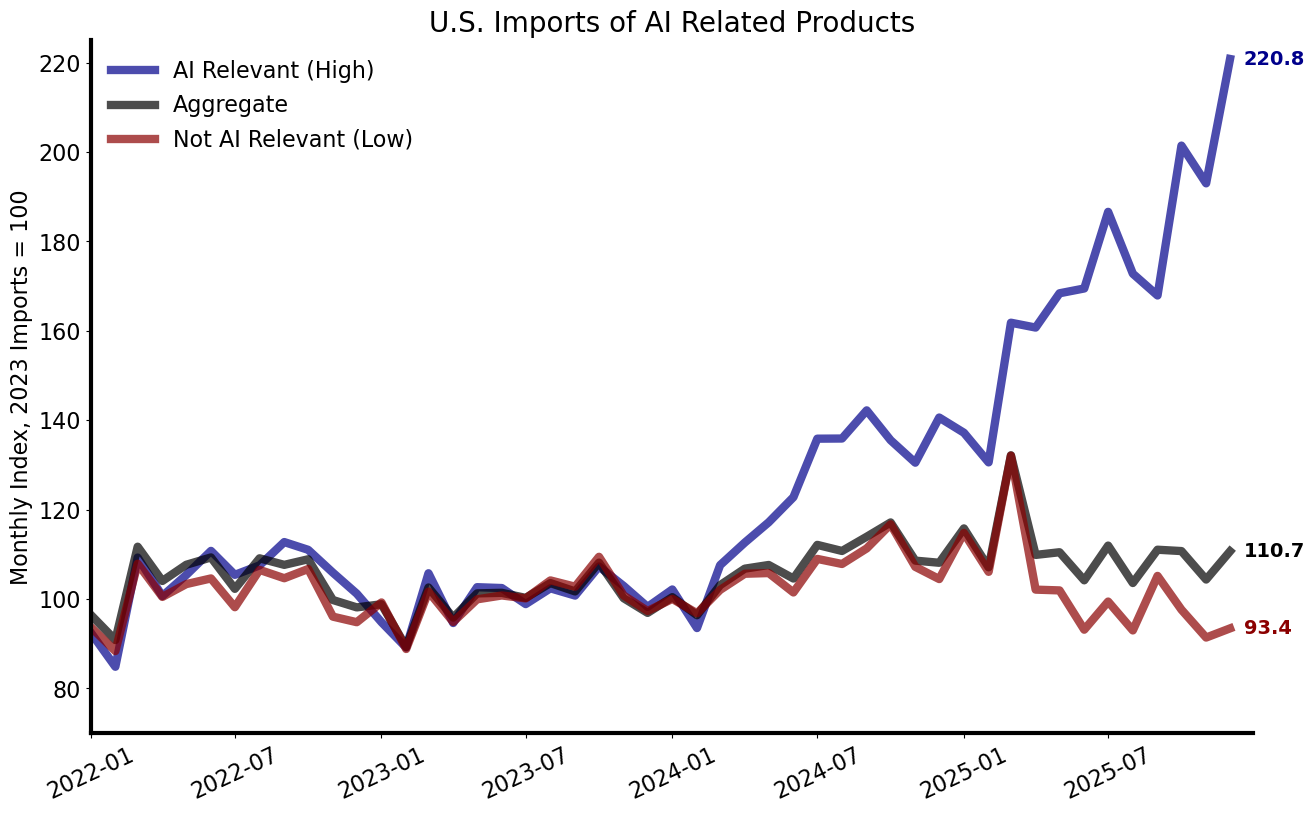

In [10]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["imports"] / foo3["imports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Add annotations for last observations
last_date_ai = foo.index[-1]
last_value_ai = 100*(12*foo["imports"].iloc[-1] / foo["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_ai:.1f}', 
            xy=(last_date_ai, last_value_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkblue',
            va='center')

last_date_agg = foo2.index[-1]
last_value_agg = 100*(12*foo2["imports"].iloc[-1] / foo2["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_agg:.1f}', 
            xy=(last_date_agg, last_value_agg),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='black',
            va='center')

last_date_not_ai = foo3.index[-1]
last_value_not_ai = 100*(12*foo3["imports"].iloc[-1] / foo3["imports"].loc["2023"].sum())
ax.annotate(f'{last_value_not_ai:.1f}', 
            xy=(last_date_not_ai, last_value_not_ai),
            xytext=(10, 0), textcoords='offset points',
            fontsize=14, fontweight='bold', color='darkred',
            va='center')

ax.set_title("U.S. Imports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,12,30)])

ax.set_ylim(70,225)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

plt.savefig(figfile+"ai-trade-index.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-trade-index.pdf", bbox_inches = "tight")

plt.show()

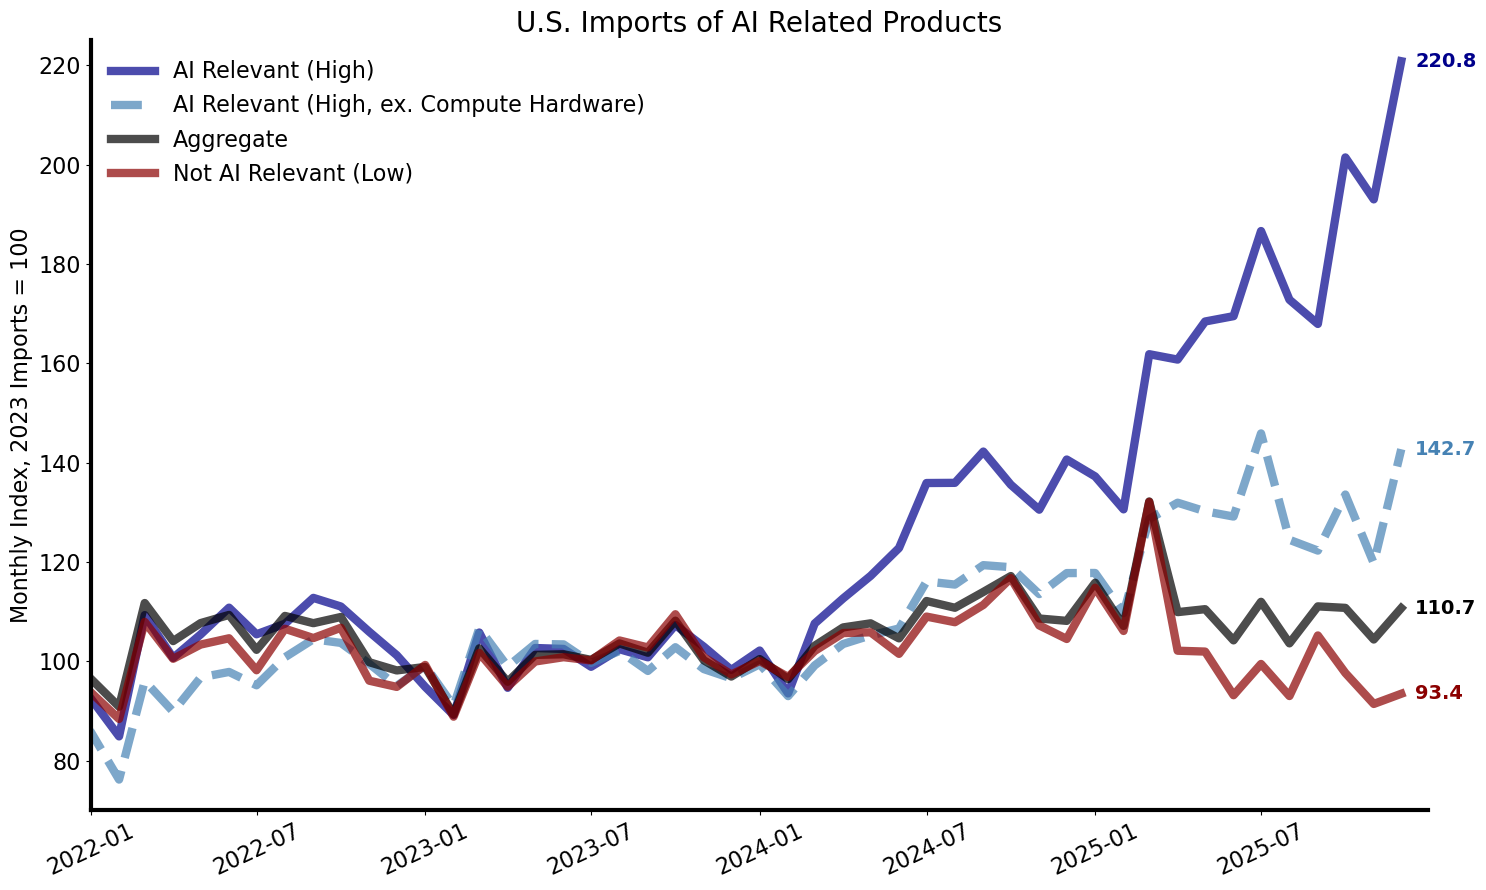

In [11]:
fig, ax = plt.subplots(figsize = (15,9))

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index('time', inplace=True)
ax.plot(foo.index, 100*(12*foo["imports"] / foo["imports"].loc["2023"].sum()) , 
        color = "darkblue", alpha = 0.7, linewidth = 6, label='AI Relevant (High)')

# High relevance, excluding Compute Hardware
foo_ex = (
    df[(df['relevance'] == 'High') & (df['primary_category'] != 'Compute_Hardware')]
    .groupby('time', observed=True)[['imports']].sum()
)
ax.plot(foo_ex.index, 100*(12*foo_ex["imports"] / foo_ex["imports"].loc["2023"].sum()) ,
        color = "steelblue", alpha = 0.7, linewidth = 6, linestyle='--',
        label='AI Relevant (High, ex. Compute Hardware)')

foo2 = grp_total.copy()
foo2.set_index('time', inplace=True)
ax.plot(foo2.index, 100*(12*foo2["imports"] / foo2["imports"].loc["2023"].sum()) ,
         color = "black", alpha = 0.7, linewidth = 6, label='Aggregate')

foo3 = grp_sum[grp_sum['relevance']=='Low'].copy()
foo3.set_index('time', inplace=True)
ax.plot(foo3.index, 100*(12*foo3["imports"] / foo3["imports"].loc["2023"].sum()) ,
         color = "darkred", alpha = 0.7, linewidth = 6, label='Not AI Relevant (Low)')

# Annotations for last observations
for series, color, label_text in [
    (foo,    "darkblue",  None),
    (foo_ex, "steelblue", None),
    (foo2,   "black",     None),
    (foo3,   "darkred",   None),
]:
    base = foo["imports"].loc["2023"].sum() if series is foo else \
           foo_ex["imports"].loc["2023"].sum() if series is foo_ex else \
           foo2["imports"].loc["2023"].sum() if series is foo2 else \
           foo3["imports"].loc["2023"].sum()
    last_date  = series.index[-1]
    last_value = 100 * (12 * series["imports"].iloc[-1] / base)
    ax.annotate(f'{last_value:.1f}',
                xy=(last_date, last_value),
                xytext=(10, 0), textcoords='offset points',
                fontsize=14, fontweight='bold', color=color,
                va='center')

ax.set_title("U.S. Imports of AI Related Products", fontsize = 20)

ax.set_xlim([dt.datetime(2022,1,1), dt.datetime(2025,12,30)])

ax.set_ylim(70, 225)

ax.tick_params(axis='x', labelsize=16, rotation=25)
ax.tick_params(axis='y', labelsize=16)

ax.set_ylabel("Monthly Index, 2023 Imports = 100", fontsize=16)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(3)
ax.spines["bottom"].set_linewidth(3)

ax.legend(
    fontsize=16,
    frameon=False,
    loc='upper left',
    ncol=1
)

plt.tight_layout()
plt.show()


In [47]:
# Export the three series to CSV
import os

# Create data-output directory if it doesn't exist
os.makedirs('data-output', exist_ok=True)

# Prepare the three series with the same transformations as in the plot
# AI Relevant (High relevance)
ai_relevant = grp_sum[grp_sum['relevance']=='High'].copy()
ai_relevant.set_index('time', inplace=True)
ai_relevant_index = 100*(12*ai_relevant["imports"] / ai_relevant["imports"].loc["2023"].sum())

# Aggregate
aggregate = grp_total.copy()
aggregate.set_index('time', inplace=True)
aggregate_index = 100*(12*aggregate["imports"] / aggregate["imports"].loc["2023"].sum())

# Not AI Relevant (Low relevance)
not_ai_relevant = grp_sum[grp_sum['relevance']=='Low'].copy()
not_ai_relevant.set_index('time', inplace=True)
not_ai_relevant_index = 100*(12*not_ai_relevant["imports"] / not_ai_relevant["imports"].loc["2023"].sum())

# Combine into a single DataFrame
export_df = pd.DataFrame({
    'date': ai_relevant_index.index,
    'AI_Relevant': ai_relevant_index.values,
    'Aggregate': aggregate_index.values,
    'Not_AI_Relevant': not_ai_relevant_index.values
})

# Filter to only include data from 2023 onwards
export_df = export_df[export_df['date'] >= '2023-01-01']

# Save to CSV
output_file = 'data-output/ai_trade_index_series.csv'
export_df.to_csv(output_file, index=False)

print(f"Successfully exported three series to {output_file}")
print(f"\nPreview of exported data:")
print(export_df.head())
print(f"\n... {len(export_df)} rows total")

Successfully exported three series to data-output/ai_trade_index_series.csv

Preview of exported data:
          date  AI_Relevant   Aggregate  Not_AI_Relevant
120 2023-01-01    94.831089   98.841990        99.241206
121 2023-02-01    89.147320   89.280026        88.825185
122 2023-03-01   105.770916  102.582313       101.666095
123 2023-04-01    94.639069   95.852326        94.872130
124 2023-05-01   102.653518  101.268108        99.936208

... 36 rows total


In [48]:
# Write key values to LaTeX file
with open(texfile, 'w') as f:
    f.write(f'\\newcommand{{\\aiRelevantIndex}}{{{last_value_ai:.0f}}} % AI-relevant imports index (2023=100)\n')
    f.write(f'\\newcommand{{\\aggregateIndex}}{{{last_value_agg:.0f}}} % Aggregate imports index (2023=100)\n')
    f.write(f'\\newcommand{{\\notAiRelevantIndex}}{{{last_value_not_ai:.0f}}} % Non-AI-relevant imports index (2023=100)\n')
    f.write(f'\\newcommand{{\\lastObsDate}}{{{last_date_ai.strftime("%B %Y")}}} % Last observation date\n')

print(f"Written to {texfile}:")
print(f"  AI Relevant Index: {last_value_ai:.0f}")
print(f"  Aggregate Index: {last_value_agg:.0f}")
print(f"  Not AI Relevant Index: {last_value_not_ai:.0f}")
print(f"  Last Observation: {last_date_ai.strftime('%B %Y')}")

Written to tables/ai-trade-results.tex:
  AI Relevant Index: 221
  Aggregate Index: 111
  Not AI Relevant Index: 93
  Last Observation: December 2025


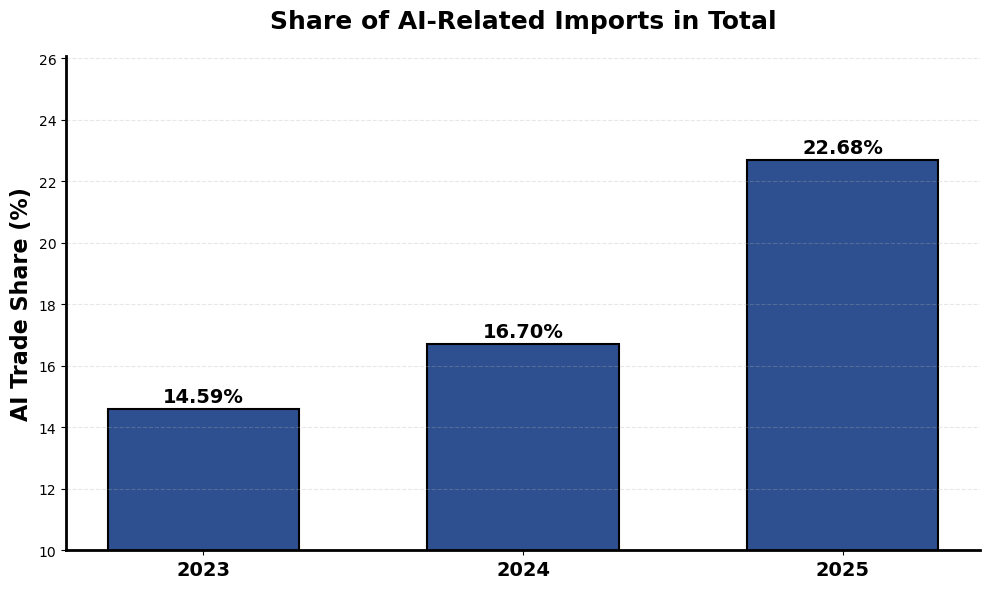


AI Trade Share:
  2023: 14.59%
  2024: 16.70%
  2025: 22.68%

Growth: 8.09 percentage points


In [49]:
# Calculate AI trade share for each year (2023-2025)
years = [2023, 2024, 2025]
ai_shares = []

foo = grp_sum[grp_sum['relevance']=='High'].copy()
foo.set_index("time", inplace=True)
df.set_index("time", inplace=True)

for year in years:
    year_str = str(year)
    total_trade = df.imports.loc[year_str].sum()
    ai_trade = foo.imports.loc[year_str].sum()
    ai_share = (ai_trade / total_trade) * 100
    ai_shares.append(ai_share)

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(years, ai_shares, color='#2E5090', edgecolor='black', linewidth=1.5, width=0.6)

# Add value labels on bars
for i, (year, share) in enumerate(zip(years, ai_shares)):
    ax.text(year, share + 0.1, f'{share:.2f}%', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Formatting
# ax.set_xlabel('Year', fontsize=16, fontweight='bold')
ax.set_ylabel('AI Trade Share (%)', fontsize=16, fontweight='bold')
ax.set_title('Share of AI-Related Imports in Total', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(years)
ax.set_ylim(10, max(ai_shares) * 1.15)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

plt.savefig(figfile+"ai-trade-share.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-trade-share.pdf", bbox_inches = "tight")

print(f"\nAI Trade Share:")
for year, share in zip(years, ai_shares):
    print(f"  {year}: {share:.2f}%")
print(f"\nGrowth: {ai_shares[-1] - ai_shares[0]:.2f} percentage points")

In [50]:
# Write AI trade share values to LaTeX file
with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\aiShareTwentyThree}}{{{ai_shares[0]:.0f}}} % AI share of total imports in 2023 (%)\n')
    f.write(f'\\newcommand{{\\aiShareTwentyFour}}{{{ai_shares[1]:.0f}}} % AI share of total imports in 2024 (%)\n')
    f.write(f'\\newcommand{{\\aiShareTwentyFive}}{{{ai_shares[2]:.0f}}} % AI share of total imports in 2025 (%)\n')
    f.write(f'\\newcommand{{\\aiShareGrowth}}{{{(ai_shares[-1] - ai_shares[0]):.0f}}} % AI share growth 2023-2025 (percentage points)\n')

print(f"\nAppended AI share values to {texfile}:")
print(f"  2023: {ai_shares[0]:.0f}%")
print(f"  2024: {ai_shares[1]:.0f}%")
print(f"  2025: {ai_shares[2]:.0f}%")
print(f"  Growth: {(ai_shares[-1] - ai_shares[0]):.0f} percentage points")


Appended AI share values to tables/ai-trade-results.tex:
  2023: 15%
  2024: 17%
  2025: 23%
  Growth: 8 percentage points


In [51]:
# Generate LaTeX table for trade values by relevance (2023 vs 2025)

import os
os.makedirs('tables', exist_ok=True)

# Calculate values for the table
df_reset = df.reset_index()

# Count unique HS10 codes by relevance
high_hs_count = df_reset[df_reset['relevance'] == 'High']['HS10'].nunique()
low_hs_count = df_reset[df_reset['relevance'] == 'Low']['HS10'].nunique()
total_hs_count = df_reset[df_reset['time'].dt.year == 2024]['HS10'].nunique()

# 2023 values
high_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'High')]['imports'].sum()
low_2023 = df_reset[(df_reset['time'].dt.year == 2023) & (df_reset['relevance'] == 'Low')]['imports'].sum()
total_2023 = df_reset[df_reset['time'].dt.year == 2023]['imports'].sum()

# 2025 values
high_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'High')]['imports'].sum()
low_2025 = df_reset[(df_reset['time'].dt.year == 2025) & (df_reset['relevance'] == 'Low')]['imports'].sum()
total_2025 = df_reset[df_reset['time'].dt.year == 2025]['imports'].sum()

# Calculate percent increases
high_pct = ((high_2025 - high_2023) / high_2023) * 100
low_pct = ((low_2025 - low_2023) / low_2023) * 100
total_pct = ((total_2025 - total_2023) / total_2023) * 100

# Generate LaTeX table
table_file = "tables/trade_by_relevance.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{U.S. Import Values by AI Relevance (2023 vs 2025)}\n")
    f.write("\\label{tab:trade_by_relevance}\n")
    f.write("\\setlength{\\tabcolsep}{4.5mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 Codes & 2023 (\\$B) & 2025 (\\$B) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    f.write(f"High AI Relevance & {high_hs_count} & {high_2023/1e9:.1f} & {high_2025/1e9:.1f} & {high_pct:+.1f} \\\\\n")
    f.write(f"Low AI Relevance & {low_hs_count} & {low_2023/1e9:.1f} & {low_2025/1e9:.1f} & {low_pct:+.1f} \\\\\n")
    f.write("\\midrule\n")
    f.write(f"Total Trade & {total_hs_count} & {total_2023/1e9:.1f} & {total_2025/1e9:.1f} & {total_pct:+.1f} \\\\\n")
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nSummary:")
print(f"  High AI Relevance: {high_hs_count} HS10 codes | ${high_2023/1e9:.1f}B (2023) → ${high_2025/1e9:.1f}B (2025) [{high_pct:+.1f}%]")
print(f"  Low AI Relevance:  {low_hs_count} HS10 codes | ${low_2023/1e9:.1f}B (2023) → ${low_2025/1e9:.1f}B (2025) [{low_pct:+.1f}%]")
print(f"  Total Trade:       {total_hs_count} HS10 codes | ${total_2023/1e9:.1f}B (2023) → ${total_2025/1e9:.1f}B (2025) [{total_pct:+.1f}%]")

Generated: tables/trade_by_relevance.tex

LaTeX Table:
\begin{table}[htbp]
\centering
\caption{U.S. Import Values by AI Relevance (2023 vs 2025)}
\label{tab:trade_by_relevance}
\setlength{\tabcolsep}{4.5mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrr}
\toprule
Category & \# HS10 Codes & 2023 (\$B) & 2025 (\$B) & Change (\%) \\
\midrule
High AI Relevance & 645 & 379.0 & 654.0 & +72.6 \\
Low AI Relevance & 15915 & 1834.7 & 1880.9 & +2.5 \\
\midrule
Total Trade & 18364 & 2598.3 & 2883.9 & +11.0 \\
\bottomrule
\end{tabular}
\end{table}


Summary:
  High AI Relevance: 645 HS10 codes | $379.0B (2023) → $654.0B (2025) [+72.6%]
  Low AI Relevance:  15915 HS10 codes | $1834.7B (2023) → $1880.9B (2025) [+2.5%]
  Total Trade:       18364 HS10 codes | $2598.3B (2023) → $2883.9B (2025) [+11.0%]


In [52]:
# Write trade by relevance values to LaTeX file
with open(texfile, 'a') as f:
    # High AI Relevance
    f.write(f'\\newcommand{{\\highAiHsCodes}}{{{high_hs_count}}} % Number of HS10 codes classified as high AI relevance\n')
    f.write(f'\\newcommand{{\\highAiTwentyThree}}{{{high_2023/1e9:.0f}}} % High AI relevance imports in 2023 ($B)\n')
    f.write(f'\\newcommand{{\\highAiTwentyFive}}{{{high_2025/1e9:.0f}}} % High AI relevance imports in 2025 ($B)\n')
    f.write(f'\\newcommand{{\\highAiPctChange}}{{{high_pct:.0f}}} % High AI relevance percent change 2023-2025\n')
    
    # Low AI Relevance
    f.write(f'\\newcommand{{\\lowAiHsCodes}}{{{low_hs_count}}} % Number of HS10 codes classified as low AI relevance\n')
    f.write(f'\\newcommand{{\\lowAiTwentyThree}}{{{low_2023/1e9:.0f}}} % Low AI relevance imports in 2023 ($B)\n')
    f.write(f'\\newcommand{{\\lowAiTwentyFive}}{{{low_2025/1e9:.0f}}} % Low AI relevance imports in 2025 ($B)\n')
    f.write(f'\\newcommand{{\\lowAiPctChange}}{{{low_pct:.0f}}} % Low AI relevance percent change 2023-2025\n')
    
    # Total Trade
    f.write(f'\\newcommand{{\\totalTradeHsCodes}}{{{total_hs_count}}} % Total number of HS10 codes in dataset\n')
    f.write(f'\\newcommand{{\\totalTradeTwentyThree}}{{{total_2023/1e9:.0f}}} % Total imports in 2023 ($B)\n')
    f.write(f'\\newcommand{{\\totalTradeTwentyFive}}{{{total_2025/1e9:.0f}}} % Total imports in 2025 ($B)\n')
    f.write(f'\\newcommand{{\\totalTradePctChange}}{{{total_pct:.0f}}} % Total trade percent change 2023-2025\n')

print(f"\nAppended trade by relevance values to {texfile}")


Appended trade by relevance values to tables/ai-trade-results.tex


In [53]:
# Generate LaTeX table for trade values by AI category (High relevance only)

import os
os.makedirs('tables', exist_ok=True)

# Calculate values for the table
df_reset = df.reset_index()

# Get high relevance only
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Get all categories (excluding Not_DC_Related, Maintenance_Operations, and NaN)
all_cats = [cat for cat in df_high_only['primary_category'].unique() 
            if pd.notna(cat) and cat != 'Not_DC_Related' and cat != 'Maintenance_Operations']

category_data = {}
for cat in all_cats:
    cat_data = df_high_only[df_high_only['primary_category'] == cat]
    
    # Count unique HS10 codes
    hs_count = cat_data['HS10'].nunique()
    
    # 2023 values
    cat_2023 = cat_data[cat_data['time'].dt.year == 2023]['imports'].sum()
    
    # 2025 values
    cat_2025 = cat_data[cat_data['time'].dt.year == 2025]['imports'].sum()
    
    # Calculate percent increase
    cat_pct = ((cat_2025 - cat_2023) / cat_2023) * 100 if cat_2023 > 0 else 0
    
    category_data[cat] = {
        'hs_count': hs_count,
        '2023': cat_2023,
        '2025': cat_2025,
        'pct': cat_pct
    }

# Calculate totals for High AI Relevance
# Sort categories by 2023 dollar value (descending)
all_cats = sorted(category_data.keys(), key=lambda x: category_data[x]['2023'], reverse=True)

# Calculate totals for High AI Relevance
total_high_hs_count = df_high_only['HS10'].nunique()
total_high_2023 = df_high_only[df_high_only['time'].dt.year == 2023]['imports'].sum()
total_high_2025 = df_high_only[df_high_only['time'].dt.year == 2025]['imports'].sum()
total_high_pct = ((total_high_2025 - total_high_2023) / total_high_2023) * 100

# Generate LaTeX table
table_file = "tables/trade_by_category.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{U.S. Import Values by AI Category, High AI Relevance (2023 vs 2025)}\n")
    f.write("\\label{tab:trade_by_category}\n")
    f.write("\\setlength{\\tabcolsep}{4.5mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 Codes & 2023 (\\$B) & 2025 (\\$B) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    
    for cat in all_cats:
        cat_name = cat.replace('_', ' ')
        data = category_data[cat]
        f.write(f"{cat_name} & {data['hs_count']} & {data['2023']/1e9:.1f} & {data['2025']/1e9:.1f} & {data['pct']:+.1f} \\\\\n")
    
    f.write("\\midrule\n")
    f.write(f"Total High AI Relevance & {total_high_hs_count} & {total_high_2023/1e9:.1f} & {total_high_2025/1e9:.1f} & {total_high_pct:+.1f} \\\\\n")
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("\nSummary by Category (High Relevance):")
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nSummary by Category (High Relevance):")
for cat in all_cats:

    data = category_data[cat]
    print(f"\n  Total High AI Relevance: {total_high_hs_count} HS10 codes | ${total_high_2023/1e9:.1f}B (2023) → ${total_high_2025/1e9:.1f}B (2025) [{total_high_pct:+.1f}%]")
    print(f"  {cat_name}: {data['hs_count']} HS10 codes | ${data['2023']/1e9:.1f}B (2023) → ${data['2025']/1e9:.1f}B (2025) [{data['pct']:+.1f}%]")

Generated: tables/trade_by_category.tex

LaTeX Table:

Summary by Category (High Relevance):
\begin{table}[htbp]
\centering
\caption{U.S. Import Values by AI Category, High AI Relevance (2023 vs 2025)}
\label{tab:trade_by_category}
\setlength{\tabcolsep}{4.5mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrr}
\toprule
Category & \# HS10 Codes & 2023 (\$B) & 2025 (\$B) & Change (\%) \\
\midrule
Compute Hardware & 163 & 144.4 & 353.8 & +144.9 \\
Electrical Power & 250 & 116.9 & 141.8 & +21.3 \\
Networking Telecom & 24 & 62.9 & 99.5 & +58.2 \\
Cooling HVAC & 137 & 41.5 & 47.5 & +14.4 \\
Building Structure & 44 & 12.1 & 10.1 & -16.5 \\
Fire Safety Security & 8 & 0.6 & 0.7 & +10.5 \\
Specialty Materials & 19 & 0.4 & 0.5 & +22.5 \\
\midrule
Total High AI Relevance & 645 & 379.0 & 654.0 & +72.6 \\
\bottomrule
\end{tabular}
\end{table}


Summary by Category (High Relevance):

  Total High AI Relevance: 645 HS10 codes | $379.0B (2023) → $654.0B (2025) [+72.6%]
  Specialty Materials: 16

In [54]:
# Write trade by category values to LaTeX file
with open(texfile, 'a') as f:
    # Each category
    for cat in all_cats:
        data = category_data[cat]
        cat_clean = cat.replace('_', '')
        cat_name = cat.replace('_', ' ')
        f.write(f'\\newcommand{{\\{cat_clean}HsCodes}}{{{data["hs_count"]}}} % Number of HS10 codes in {cat_name}\n')
        f.write(f'\\newcommand{{\\{cat_clean}TwentyThree}}{{{data["2023"]/1e9:.0f}}} % {cat_name} imports in 2023 ($B)\n')
        f.write(f'\\newcommand{{\\{cat_clean}TwentyFive}}{{{data["2025"]/1e9:.0f}}} % {cat_name} imports in 2025 ($B)\n')
        f.write(f'\\newcommand{{\\{cat_clean}PctChange}}{{{data["pct"]:.0f}}} % {cat_name} percent change 2023-2025\n')
    
    # Total High AI Relevance
    f.write(f'\\newcommand{{\\totalHighAiHsCodes}}{{{total_high_hs_count}}} % Total HS10 codes across all high AI categories\n')
    f.write(f'\\newcommand{{\\totalHighAiTwentyThree}}{{{total_high_2023/1e9:.0f}}} % Total high AI imports in 2023 ($B)\n')
    f.write(f'\\newcommand{{\\totalHighAiTwentyFive}}{{{total_high_2025/1e9:.0f}}} % Total high AI imports in 2025 ($B)\n')
    f.write(f'\\newcommand{{\\totalHighAiPctChange}}{{{total_high_pct:.0f}}} % Total high AI percent change 2023-2025\n')

print(f"\nAppended trade by category values to {texfile}")


Appended trade by category values to tables/ai-trade-results.tex


In [55]:
# Generate combined hierarchical LaTeX table for trade values
# Shows High AI Relevance with subcategories, then Low AI Relevance, then Total

import os
os.makedirs('tables', exist_ok=True)

# Use the data already calculated in previous cells
# high_hs_count, high_2023, high_2025, high_pct (from relevance table)
# low_hs_count, low_2023, low_2025, low_pct (from relevance table)
# total_hs_count, total_2023, total_2025, total_pct (from relevance table)
# category_data, all_cats (from category table)

# Generate combined hierarchical table
table_file = "tables/trade_hierarchical.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\caption{U.S. Import Values by AI Relevance and Category (2023 vs 2025)}\n")
    f.write("\\label{tab:trade_hierarchical}\n")
    f.write("\\setlength{\\tabcolsep}{4.5mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.60}\n")
    f.write("\\begin{tabular}{lrrrr}\n")
    f.write("\\toprule\n")
    f.write("Category & \\# HS10 Codes & 2023 (\\$B) & 2025 (\\$B) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    
    # High AI Relevance (main row)
    f.write(f"High AI Relevance & {high_hs_count} & {high_2023/1e9:.1f} & {high_2025/1e9:.1f} & {high_pct:+.1f} \\\\\n")
    
    # Subcategories (indented)
    for cat in all_cats:
        cat_name = cat.replace('_', ' ')
        data = category_data[cat]
        # Use \quad\quad for indentation
        f.write(f"\\quad\\quad {cat_name} & {data['hs_count']} & {data['2023']/1e9:.1f} & {data['2025']/1e9:.1f} & {data['pct']:+.1f} \\\\\n")
    
    # Low AI Relevance
    f.write(f"Low AI Relevance & {low_hs_count} & {low_2023/1e9:.1f} & {low_2025/1e9:.1f} & {low_pct:+.1f} \\\\\n")
    
    f.write("\\midrule\n")
    
    # Total Trade
    f.write(f"Total Trade & {total_hs_count} & {total_2023/1e9:.1f} & {total_2025/1e9:.1f} & {total_pct:+.1f} \\\\\n")
    
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nSummary:")
print(f"High AI Relevance: {high_hs_count} HS10 codes | ${high_2023/1e9:.1f}B (2023) → ${high_2025/1e9:.1f}B (2025) [{high_pct:+.1f}%]")
for cat in all_cats:
    data = category_data[cat]
    cat_name = cat.replace('_', ' ')
    print(f"  └─ {cat_name}: {data['hs_count']} HS10 codes | ${data['2023']/1e9:.1f}B (2023) → ${data['2025']/1e9:.1f}B (2025) [{data['pct']:+.1f}%]")
print(f"Low AI Relevance: {low_hs_count} HS10 codes | ${low_2023/1e9:.1f}B (2023) → ${low_2025/1e9:.1f}B (2025) [{low_pct:+.1f}%]")
print(f"Total Trade: {total_hs_count} HS10 codes | ${total_2023/1e9:.1f}B (2023) → ${total_2025/1e9:.1f}B (2025) [{total_pct:+.1f}%]")

Generated: tables/trade_hierarchical.tex

LaTeX Table:
\begin{table}[htbp]
\centering
\caption{U.S. Import Values by AI Relevance and Category (2023 vs 2025)}
\label{tab:trade_hierarchical}
\setlength{\tabcolsep}{4.5mm}
\renewcommand{\arraystretch}{1.60}
\begin{tabular}{lrrrr}
\toprule
Category & \# HS10 Codes & 2023 (\$B) & 2025 (\$B) & Change (\%) \\
\midrule
High AI Relevance & 645 & 379.0 & 654.0 & +72.6 \\
\quad\quad Compute Hardware & 163 & 144.4 & 353.8 & +144.9 \\
\quad\quad Electrical Power & 250 & 116.9 & 141.8 & +21.3 \\
\quad\quad Networking Telecom & 24 & 62.9 & 99.5 & +58.2 \\
\quad\quad Cooling HVAC & 137 & 41.5 & 47.5 & +14.4 \\
\quad\quad Building Structure & 44 & 12.1 & 10.1 & -16.5 \\
\quad\quad Fire Safety Security & 8 & 0.6 & 0.7 & +10.5 \\
\quad\quad Specialty Materials & 19 & 0.4 & 0.5 & +22.5 \\
Low AI Relevance & 15915 & 1834.7 & 1880.9 & +2.5 \\
\midrule
Total Trade & 18364 & 2598.3 & 2883.9 & +11.0 \\
\bottomrule
\end{tabular}
\end{table}


Summary:
High AI R

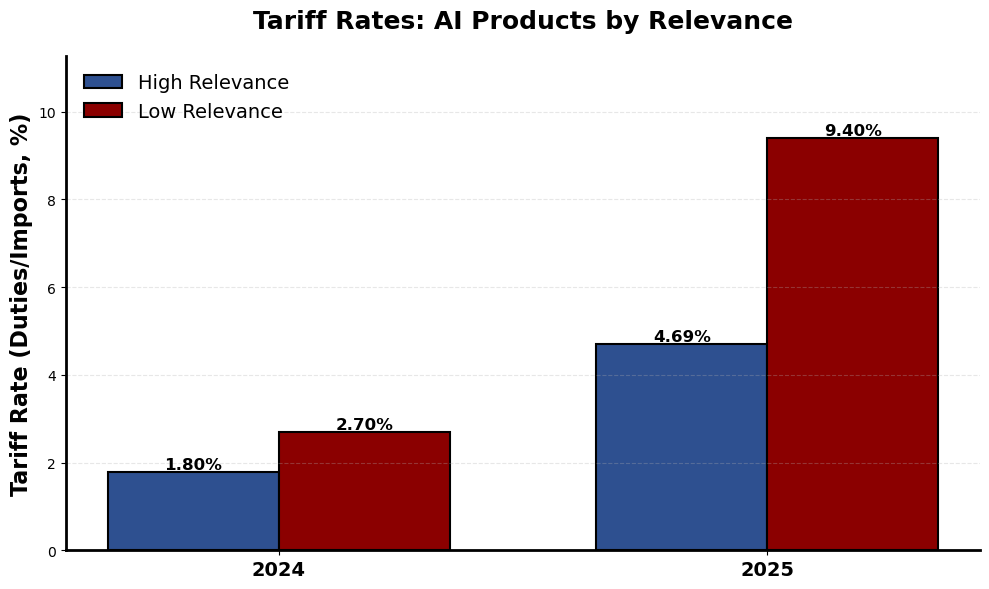


Tariff Rates (Duties/Imports):
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  2025:
    High Relevance: 4.69%
    Low Relevance:  9.40%


In [56]:
# Calculate tariff rates (duty/imports) for High vs Low relevance products
# for 2024 and 2025

df_reset = df.reset_index()

years = [2024, 2025]
tariff_data = {'High': [], 'Low': []}

for year in years:
    year_str = str(year)
    year_data = df_reset[df_reset['time'].dt.year == year]
    
    for rel in ['High', 'Low']:
        rel_data = year_data[year_data['relevance'] == rel]
        total_duty = rel_data['duty'].sum()
        total_imports = rel_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        tariff_data[rel].append(tariff_rate)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(years))
width = 0.35

bars1 = ax.bar(x - width/2, tariff_data['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, tariff_data['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting
ax.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=16, fontweight='bold')
ax.set_title('Tariff Rates: AI Products by Relevance', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylim(0, max(max(tariff_data['High']), max(tariff_data['Low'])) * 1.2)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Make x-tick labels bold and larger
ax.tick_params(axis='x', labelsize=14)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

ax.legend(fontsize=14, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()



print(f"\nTariff Rates (Duties/Imports):")
for i, year in enumerate(years):
    print(f"  {year}:")
    print(f"    High Relevance: {tariff_data['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data['Low'][i]:.2f}%")

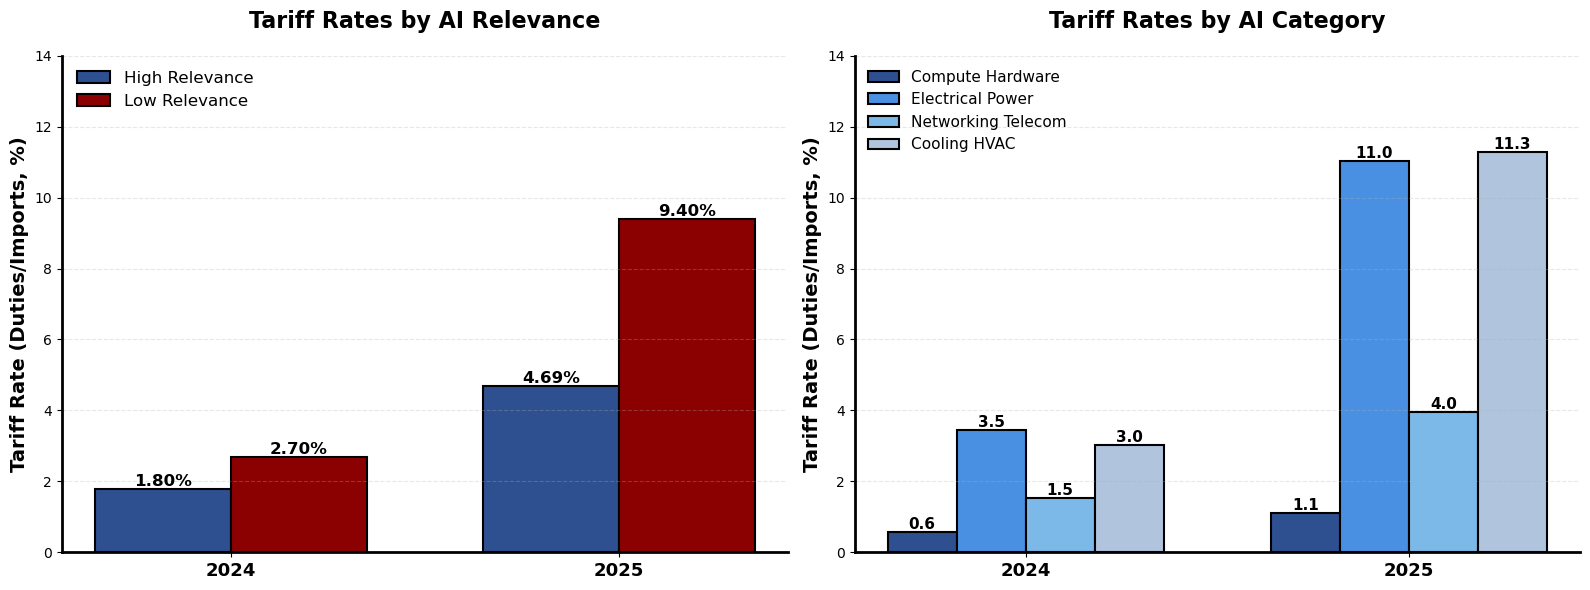


Tariff Rates Summary:

By Relevance:
  2024:
    High Relevance: 1.80%
    Low Relevance:  2.70%
  2025:
    High Relevance: 4.69%
    Low Relevance:  9.40%

By Category (High Relevance only):
  Compute Hardware:
    2024: 0.56%
    2025: 1.11%
  Electrical Power:
    2024: 3.46%
    2025: 11.04%
  Networking Telecom:
    2024: 1.54%
    2025: 3.96%
  Cooling HVAC:
    2024: 3.04%
    2025: 11.28%


In [57]:
# Two-panel figure: Tariff rates by category (left) and by relevance (right)

years = [2024, 2025]
df_reset = df.reset_index()

# Calculate tariff rates for relevance comparison (High vs Low)
tariff_data_relevance = {'High': [], 'Low': []}
for year in years:
    year_data = df_reset[df_reset['time'].dt.year == year]
    
    for rel in ['High', 'Low']:
        rel_data = year_data[year_data['relevance'] == rel]
        total_duty = rel_data['duty'].sum()
        total_imports = rel_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        tariff_data_relevance[rel].append(tariff_rate)

# Calculate tariff rates for category breakdown (only top 4 categories)
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()
top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

category_tariffs_subset = {}
for cat in top_4_cats:
    category_tariffs_subset[cat] = []
    for year in years:
        year_data = df_high_only[(df_high_only['time'].dt.year == year) & 
                                  (df_high_only['primary_category'] == cat)]
        total_duty = year_data['duty'].sum()
        total_imports = year_data['imports'].sum()
        tariff_rate = (total_duty / total_imports) * 100 if total_imports > 0 else 0
        category_tariffs_subset[cat].append(tariff_rate)

# Create two-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT PANEL: Tariff rates by relevance (High vs Low)
x = np.arange(len(years))
width = 0.35

bars1 = ax1.bar(x - width/2, tariff_data_relevance['High'], width, 
               label='High Relevance', color='#2E5090', edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, tariff_data_relevance['Low'], width,
               label='Low Relevance', color='#8B0000', edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting left panel
ax1.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax1.set_title('Tariff Rates by AI Relevance', fontsize=16, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.set_ylim(0, 14)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.tick_params(axis='x', labelsize=13)
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.spines["left"].set_linewidth(2)
ax1.spines["bottom"].set_linewidth(2)
ax1.legend(fontsize=12, frameon=False, loc='upper left')

# RIGHT PANEL: Tariff rates by category (4 categories only)
x = np.arange(len(years))
width = 0.18
n_cats = len(category_tariffs_subset)
offset = np.arange(n_cats) - (n_cats - 1) / 2

colors_cat = ['#2E5090', '#4A90E2', '#7CB9E8', '#B0C4DE']

for i, (cat, tariffs) in enumerate(category_tariffs_subset.items()):
    label = cat.replace('_', ' ')
    bars = ax2.bar(x + offset[i] * width, tariffs, width, 
                   label=label, color=colors_cat[i], 
                   edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Formatting right panel
ax2.set_ylabel('Tariff Rate (Duties/Imports, %)', fontsize=14, fontweight='bold')
ax2.set_title('Tariff Rates by AI Category', fontsize=16, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_ylim(0, 14)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.tick_params(axis='x', labelsize=13)
for label in ax2.get_xticklabels():
    label.set_fontweight('bold')
ax2.spines["right"].set_visible(False)
ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_linewidth(2)
ax2.spines["bottom"].set_linewidth(2)
ax2.legend(fontsize=11, frameon=False, loc='upper left', ncol=1)

plt.savefig(figfile+"ai-tariffs.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-tariffs.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()



print(f"\nTariff Rates Summary:")
print(f"\nBy Relevance:")
for i, year in enumerate(years):
    print(f"  {year}:")
    print(f"    High Relevance: {tariff_data_relevance['High'][i]:.2f}%")
    print(f"    Low Relevance:  {tariff_data_relevance['Low'][i]:.2f}%")

print(f"\nBy Category (High Relevance only):")
for cat, tariffs in category_tariffs_subset.items():
    print(f"  {cat.replace('_', ' ')}:")
    for i, year in enumerate(years):
        print(f"    {year}: {tariffs[i]:.2f}%")

In [58]:
# Write tariff rate values to LaTeX file
with open(texfile, 'a') as f:
    # Tariff rates by relevance
    f.write(f'\\newcommand{{\\tariffHighTwentyFour}}{{{tariff_data_relevance["High"][0]:.1f}}} % High AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\newcommand{{\\tariffHighTwentyFive}}{{{tariff_data_relevance["High"][1]:.1f}}} % High AI relevance tariff rate in 2025 (%)\n')
    f.write(f'\\newcommand{{\\tariffLowTwentyFour}}{{{tariff_data_relevance["Low"][0]:.1f}}} % Low AI relevance tariff rate in 2024 (%)\n')
    f.write(f'\\newcommand{{\\tariffLowTwentyFive}}{{{tariff_data_relevance["Low"][1]:.1f}}} % Low AI relevance tariff rate in 2025 (%)\n')
    
    # Tariff rates by category
    for cat in top_4_cats:
        cat_clean = cat.replace('_', '')
        cat_name = cat.replace('_', ' ')
        tariffs = category_tariffs_subset[cat]
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFour}}{{{tariffs[0]:.1f}}} % {cat_name} tariff rate in 2024 (%)\n')
        f.write(f'\\newcommand{{\\tariff{cat_clean}TwentyFive}}{{{tariffs[1]:.1f}}} % {cat_name} tariff rate in 2025 (%)\n')

print(f"\nAppended tariff rate values to {texfile}")
print(f"\nBy Relevance:")
print(f"  High: {tariff_data_relevance['High'][0]:.1f}% (2024), {tariff_data_relevance['High'][1]:.1f}% (2025)")
print(f"  Low: {tariff_data_relevance['Low'][0]:.1f}% (2024), {tariff_data_relevance['Low'][1]:.1f}% (2025)")
print(f"\nBy Category:")
for cat in top_4_cats:
    tariffs = category_tariffs_subset[cat]
    print(f"  {cat.replace('_', ' ')}: {tariffs[0]:.1f}% (2024), {tariffs[1]:.1f}% (2025)")


Appended tariff rate values to tables/ai-trade-results.tex

By Relevance:
  High: 1.8% (2024), 4.7% (2025)
  Low: 2.7% (2024), 9.4% (2025)

By Category:
  Compute Hardware: 0.6% (2024), 1.1% (2025)
  Electrical Power: 3.5% (2024), 11.0% (2025)
  Networking Telecom: 1.5% (2024), 4.0% (2025)
  Cooling HVAC: 3.0% (2024), 11.3% (2025)


In [59]:
# Top 5 HS10 codes within each top category (High relevance only)

top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

df_reset = df.reset_index()
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

for cat in top_4_cats:
    print(f"\n{'='*80}")
    print(f"{cat.replace('_', ' ')}")
    print('='*80)
    
    # Filter to this category
    cat_data = df_high_only[df_high_only['primary_category'] == cat].copy()
    
    # Get total imports for this category
    cat_total = cat_data['imports'].sum()
    
    # Group by HS10 and sum imports
    hs10_imports = cat_data.groupby('HS10')['imports'].sum().sort_values(ascending=False)
    
    # Get top 5
    top_5_hs10 = hs10_imports.head(5)
    
    # Get descriptions from df and matlist
    for rank, (hs10, imports) in enumerate(top_5_hs10.items(), 1):
        fraction = (imports / cat_total) * 100
        
        # Get description from df and reasoning from matlist
        desc_row_df = cat_data[cat_data['HS10'] == hs10]
        desc_row_matlist = matlist[matlist['HS10'] == hs10]
        
        if len(desc_row_df) > 0:
            description = desc_row_df.iloc[0].get('short_description', 'No description available')
        else:
            description = 'Description not found'
            
        if len(desc_row_matlist) > 0:
            llm_reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
        else:
            llm_reasoning = 'Reasoning not found'

        
        print(f"   Reasoning: {llm_reasoning}")
        print(f"\n{rank}. HS10: {hs10}")        
        print(f"   Description: {description}")
        print(f"   Share of {cat.replace('_', ' ')}: {fraction:.2f}%")


Compute Hardware
   Reasoning: Digital processing units are core compute components used in data center servers. The NAICS classification confirms these are electronic computer components. These would include CPUs, GPUs, and other processors essential for AI training and inference operations in data centers.

1. HS10: 8471500150
   Description: PROC UNT IN HOUS W/ EITHER STOR, IN&OUTPUT,W/O CRT
   Share of Compute Hardware: 28.90%
   Reasoning: Electronic integrated circuits including processors and controllers are core components of AI data center compute infrastructure. These are essential for servers running AI workloads, whether CPUs for general processing or specialized processors for AI acceleration. The NAICS code 334413 confirms these are semiconductor devices, which are fundamental to data center operations.

2. HS10: 8542310001
   Description: PROCESSORS & CONTOLLERS W/NOT COMBO W MEMORIS, ETC
   Share of Compute Hardware: 8.94%
   Reasoning: This product covers parts and ac

In [60]:
# Generate LaTeX tables for top 5 HS10 codes in each category

import os

# Create output directory if it doesn't exist
os.makedirs('tables', exist_ok=True)

def escape_latex(text):
    """Escape special LaTeX characters"""
    if pd.isna(text):
        return ''
    text = str(text)
    
    # First, escape backslash and special characters BEFORE adding math symbols
    text = text.replace('\\', r'\textbackslash{}')
    replacements = {
        '&': r'\&',
        '%': r'\%',
        '$': r'\$',
        '#': r'\#',
        '_': r'\_',
        '{': r'\{',
        '}': r'\}',
        '~': r'\textasciitilde{}',
        '^': r'\textasciicircum{}',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    
    # THEN replace Unicode math symbols with LaTeX equivalents (after $ is already escaped)
    unicode_math = {
        '≤': r'$\leq$',
        '≥': r'$\geq$',
        '≠': r'$\neq$',
        '≈': r'$\approx$',
        '×': r'$\times$',
        '÷': r'$\div$',
        '±': r'$\pm$',
        '°': r'$^\circ$',
        'μ': r'$\mu$',
        'Ω': r'$\Omega$',
        '→': r'$\rightarrow$',
        '←': r'$\leftarrow$',
    }
    for unicode_char, latex_cmd in unicode_math.items():
        text = text.replace(unicode_char, latex_cmd)
    
    return text

top_4_cats = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

df_reset = df.reset_index()
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Filter to 2023 and 2025 data
df_2023 = df_high_only[df_high_only['time'].dt.year == 2023].copy()
df_2025 = df_high_only[df_high_only['time'].dt.year == 2025].copy()

# Generate combined file with all 4 tables
combined_file = "tables/top5_all_categories.tex"
with open(combined_file, 'w', encoding='utf-8') as f:
    f.write("% Top 5 HS10 Codes for All AI Categories\n\n")
    
    for cat in top_4_cats:
        # Filter to this category for 2025 (to rank by 2025 imports)
        cat_data_2025 = df_2025[df_2025['primary_category'] == cat].copy()
        cat_data_2023 = df_2023[df_2023['primary_category'] == cat].copy()
        
        # Group by HS10 and sum imports for 2025 (for ranking)
        hs10_imports_2025 = cat_data_2025.groupby('HS10')['imports'].sum().sort_values(ascending=False)
        hs10_imports_2023 = cat_data_2023.groupby('HS10')['imports'].sum()
        
        # Get top 5 by 2025 imports
        top_5_hs10 = hs10_imports_2025.head(5)
        
        # Generate LaTeX table for this category
        f.write("\\begin{table}[htbp]\n")
        f.write("\\centering\n")
        f.write("\\small\n")
        f.write("\\caption{Top 5 HS10 Codes in " + cat.replace('_', ' ') + "}\n")
        f.write("\\label{tab:top5_" + cat.lower() + "}\n")
        f.write("\\setlength{\\tabcolsep}{1.25mm}\n")
        f.write("\\renewcommand{\\arraystretch}{1.80}\n")
        f.write("\\begin{tabular}{lp{3.5cm}p{3.5cm}cc}\n")
        f.write("\\toprule\n")
        f.write("HS10 Code & Description & LLM Reasoning & 2025 Imports (\\$B) & Change (\\%) \\\\\n")
        f.write("\\midrule\n")
        
        for rank, (hs10, imports_2025) in enumerate(top_5_hs10.items(), 1):
            imports_billions = imports_2025 / 1e9
            
            # Calculate percent change from 2023 to 2025
            imports_2023 = hs10_imports_2023.get(hs10, 0)
            if imports_2023 > 0:
                pct_change = ((imports_2025 - imports_2023) / imports_2023) * 100
            else:
                pct_change = 0
            
            # Get description from df and reasoning from matlist
            desc_row_df = cat_data_2025[cat_data_2025['HS10'] == hs10]
            desc_row_matlist = matlist[matlist['HS10'] == hs10]
            
            if len(desc_row_df) > 0:
                description = desc_row_df.iloc[0].get('short_description', 'No description available')
            else:
                description = 'Description not found'
                
            if len(desc_row_matlist) > 0:
                reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
            else:
                reasoning = 'Reasoning not found'
            
            # Extract only first sentence from reasoning
            reasoning = reasoning.split('.')[0] + '.' if '.' in reasoning else reasoning
            
            # Keep description and reasoning as-is without sentence case conversion
            
            # Escape LaTeX special characters
            description_escaped = escape_latex(description)
            reasoning_escaped = escape_latex(reasoning)
            
            f.write(f"{hs10} & {{\\footnotesize {description_escaped}}} & {{\\footnotesize {reasoning_escaped}}} & {imports_billions:.2f} & {pct_change:+.1f} \\\\\n")
        
        f.write("\\bottomrule\n")
        f.write("\\end{tabular}\n")
        f.write("\\end{table}\n\n")


print(f"Generated: {combined_file}")
print("\nRequired packages: \\usepackage{booktabs}")
print("  - \\input{tables/top5_all_categories.tex}")
print("\nTo use in your LaTeX document:")

Generated: tables/top5_all_categories.tex

Required packages: \usepackage{booktabs}
  - \input{tables/top5_all_categories.tex}

To use in your LaTeX document:


In [61]:
# Generate LaTeX table for top 10 HS10 codes across all high relevance categories (by 2025 imports)

import os
os.makedirs('tables', exist_ok=True)

df_reset = df.reset_index()
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Filter to 2025 and 2023 data and group by HS10
df_2025 = df_high_only[df_high_only['time'].dt.year == 2025].copy()
df_2023 = df_high_only[df_high_only['time'].dt.year == 2023].copy()

hs10_imports_2025 = df_2025.groupby('HS10')['imports'].sum().sort_values(ascending=False)
hs10_imports_2023 = df_2023.groupby('HS10')['imports'].sum()

# Get top 10
top_10_hs10 = hs10_imports_2025.head(10)

# Calculate total trade imports in 2025 for percentage calculation
total_trade_2025 = df_reset[df_reset['time'].dt.year == 2025]['imports'].sum()

# Generate LaTeX table
table_file = "tables/top10_high_relevance.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\small\n")
    f.write("\\caption{Top 10 HS10 Codes by 2025 Import Volume, High AI Relevance}\n")
    f.write("\\label{tab:top10_high_relevance}\n")
    f.write("\\setlength{\\tabcolsep}{1.25mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.80}\n")
    f.write("\\begin{tabular}{lp{5cm}lccc}\n")
    f.write("\\toprule\n")
    f.write("HS10 Code & Description & Category & 2025 Imports (\\$B) & Share of Total Trade (\\%) & Change (\\%) " + r"\\")
    f.write("\n")
    f.write("\\midrule\n")

    for rank, (hs10, imports) in enumerate(top_10_hs10.items(), 1):
        fraction = (imports / total_trade_2025) * 100
        imports_billions = imports / 1e9

        # Calculate percent change from 2023 to 2025
        imports_2023 = hs10_imports_2023.get(hs10, 0)
        if imports_2023 > 0:
            pct_change = ((imports - imports_2023) / imports_2023) * 100
        else:
            pct_change = 0

        # Get description from df and category from matlist
        desc_row_df = df_2025[df_2025['HS10'] == hs10]
        desc_row_matlist = matlist[matlist['HS10'] == hs10]

        if len(desc_row_df) > 0:
            description = desc_row_df.iloc[0].get('short_description', 'No description available')
        else:
            description = 'Description not found'

        if len(desc_row_matlist) > 0:
            category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
        else:
            category = 'Unknown'

        # Keep description as-is without sentence case conversion to preserve original formatting

        # Format category name
        category_formatted = category.replace('_', ' ')

        # Escape LaTeX special characters
        description_escaped = escape_latex(description)
        category_escaped = escape_latex(category_formatted)

        f.write(f"{hs10} & {{\\footnotesize {description_escaped}}} & {category_escaped} & {imports_billions:.2f} & {fraction:.2f} & {pct_change:+.1f} " + r"\\")
        f.write("\n")

    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")

print(f"Generated: {table_file}\n")
print("LaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nTop 10 HS10 Codes by 2025 Import Volume:")
for rank, (hs10, imports) in enumerate(top_10_hs10.items(), 1):
    fraction = (imports / total_trade_2025) * 100

    # Calculate percent change from 2023 to 2025
    imports_2023 = hs10_imports_2023.get(hs10, 0)
    if imports_2023 > 0:
        pct_change = ((imports - imports_2023) / imports_2023) * 100
    else:
        pct_change = 0

    desc_row_df = df_2025[df_2025['HS10'] == hs10]
    desc_row_matlist = matlist[matlist['HS10'] == hs10]

    if len(desc_row_df) > 0:
        description = desc_row_df.iloc[0].get('short_description', 'No description')
    else:
        description = 'Description not found'

    if len(desc_row_matlist) > 0:
        category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
    else:
        category = 'Unknown'
    print(f"{rank}. HS10: {hs10} | {category.replace('_', ' ')} | ${imports/1e9:.2f}B | {fraction:.2f}% | Change: {pct_change:+.1f}% | {description[:60]}...")

Generated: tables/top10_high_relevance.tex

LaTeX Table:
\begin{table}[htbp]
\centering
\small
\caption{Top 10 HS10 Codes by 2025 Import Volume, High AI Relevance}
\label{tab:top10_high_relevance}
\setlength{\tabcolsep}{1.25mm}
\renewcommand{\arraystretch}{1.80}
\begin{tabular}{lp{5cm}lccc}
\toprule
HS10 Code & Description & Category & 2025 Imports (\$B) & Share of Total Trade (\%) & Change (\%) \\
\midrule
8471500150 & {\footnotesize PROC UNT IN HOUS W/ EITHER STOR, IN\&OUTPUT,W/O CRT} & Compute Hardware & 163.55 & 5.67 & +343.0 \\
8517620090 & {\footnotesize MACH FOR RECP/CONVER ETC OF VOICE/IMAGE/DATA NESOI} & Networking Telecom & 52.88 & 1.83 & +58.3 \\
8473301180 & {\footnotesize PTS ADP MCH, NT INCPTNG CRT,PRT CRT ASSEM.;NESOI} & Compute Hardware & 48.89 & 1.70 & +199.8 \\
8517620020 & {\footnotesize SWITCHING AND ROUTING APPARATUS} & Networking Telecom & 30.76 & 1.07 & +89.1 \\
8473301140 & {\footnotesize PTS ADP MCH, NT INCPTG CRT,PRT CT ASM.,MRY MODULES} & Compute Hardware & 2

In [62]:
# Generate LANDSCAPE LaTeX table for top 10 HS10 codes with LLM reasoning included

import os
os.makedirs('tables', exist_ok=True)

# Recalculate the data to ensure we have the correct values
df_reset = df.reset_index()
df_high_only = df_reset[df_reset['relevance'] == 'High'].copy()

# Filter to 2025 and 2023 data and group by HS10
df_2025_landscape = df_high_only[df_high_only['time'].dt.year == 2025].copy()
df_2023_landscape = df_high_only[df_high_only['time'].dt.year == 2023].copy()

hs10_imports_2025_landscape = df_2025_landscape.groupby('HS10')['imports'].sum().sort_values(ascending=False)
hs10_imports_2023_landscape = df_2023_landscape.groupby('HS10')['imports'].sum()

# Get top 10
top_10_hs10_landscape = hs10_imports_2025_landscape.head(10)

# Calculate total trade imports in 2025 for percentage calculation
total_trade_2025_landscape = df_reset[df_reset['time'].dt.year == 2025]['imports'].sum()

# Generate LaTeX table with landscape format
table_file = "tables/top10_high_relevance_landscape.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{landscape}\n")
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\footnotesize\n")
    f.write("\\caption{Top 10 HS10 Codes by 2025 Import Volume with High AI Relevance}\n")
    f.write("\\label{tab:top10_high_relevance_landscape}\n")
    f.write("\\setlength{\\tabcolsep}{2mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.0}\n")
    f.write("\\begin{tabular}{lp{4cm}lp{6cm}ccc}\n")
    f.write("\\toprule\n")
    f.write("HS10 Code & Description & Category & LLM Reasoning & 2025 Imports (\\$B) & Share of Trade (\\%) & Change (\\%) " + r"\\")
    f.write("\n")
    f.write("\\midrule\n")

    for rank, (hs10, imports) in enumerate(top_10_hs10_landscape.items(), 1):
        fraction = (imports / total_trade_2025_landscape) * 100
        imports_billions = imports / 1e9

        # Calculate percent change from 2023 to 2025
        imports_2023 = hs10_imports_2023_landscape.get(hs10, 0)
        if imports_2023 > 0:
            pct_change = ((imports - imports_2023) / imports_2023) * 100
        else:
            pct_change = 0

        # Get description from df, category and reasoning from matlist
        desc_row_df = df_2025_landscape[df_2025_landscape['HS10'] == hs10]
        desc_row_matlist = matlist[matlist['HS10'] == hs10]

        if len(desc_row_df) > 0:
            description = desc_row_df.iloc[0].get('short_description', 'No description available')
        else:
            description = 'Description not found'

        if len(desc_row_matlist) > 0:
            category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
            reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
        else:
            category = 'Unknown'
            reasoning = 'Reasoning not found'

        # Extract only first sentence from reasoning
        reasoning = reasoning.split('.')[0] + '.' if '.' in reasoning else reasoning

        # Format category name
        category_formatted = category.replace('_', ' ')

        # Escape LaTeX special characters
        description_escaped = escape_latex(description)
        category_escaped = escape_latex(category_formatted)
        reasoning_escaped = escape_latex(reasoning)

        f.write(f"{hs10} & {{\\scriptsize {description_escaped}}} & {category_escaped} & {{\\scriptsize {reasoning_escaped}}} & {imports_billions:.2f} & {fraction:.2f} & {pct_change:+.1f} " + r"\\")
        f.write("\n")

    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")
    f.write("\\end{landscape}\n")

print(f"Generated: {table_file}\n")
print("Required packages: \\usepackage{booktabs}, \\usepackage{lscape}")
print(f"  - \\input{{{table_file}}}")
print("\nLaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nTop 10 HS10 Codes with LLM Reasoning (Landscape Format):")
for rank, (hs10, imports) in enumerate(top_10_hs10_landscape.items(), 1):
    fraction = (imports / total_trade_2025_landscape) * 100
    imports_2023 = hs10_imports_2023_landscape.get(hs10, 0)
    if imports_2023 > 0:
        pct_change = ((imports - imports_2023) / imports_2023) * 100
    else:
        pct_change = 0

    desc_row_matlist = matlist[matlist['HS10'] == hs10]
    if len(desc_row_matlist) > 0:
        category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
        reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
    else:
        category = 'Unknown'
        reasoning = 'Reasoning not found'

    reasoning_short = reasoning.split('.')[0] + '.' if '.' in reasoning else reasoning
    print(f"{rank}. HS10: {hs10} | {category.replace('_', ' ')} | ${imports/1e9:.2f}B (2025) | ${imports_2023/1e9:.2f}B (2023) | {fraction:.2f}% | Change: {pct_change:+.1f}%")
    print(f"   Reasoning: {reasoning_short}")

Generated: tables/top10_high_relevance_landscape.tex

Required packages: \usepackage{booktabs}, \usepackage{lscape}
  - \input{tables/top10_high_relevance_landscape.tex}

LaTeX Table:
\begin{landscape}
\begin{table}[htbp]
\centering
\footnotesize
\caption{Top 10 HS10 Codes by 2025 Import Volume with High AI Relevance}
\label{tab:top10_high_relevance_landscape}
\setlength{\tabcolsep}{2mm}
\renewcommand{\arraystretch}{1.0}
\begin{tabular}{lp{4cm}lp{6cm}ccc}
\toprule
HS10 Code & Description & Category & LLM Reasoning & 2025 Imports (\$B) & Share of Trade (\%) & Change (\%) \\
\midrule
8471500150 & {\scriptsize PROC UNT IN HOUS W/ EITHER STOR, IN\&OUTPUT,W/O CRT} & Compute Hardware & {\scriptsize Digital processing units are core compute components used in data center servers.} & 163.55 & 5.67 & +343.0 \\
8517620090 & {\scriptsize MACH FOR RECP/CONVER ETC OF VOICE/IMAGE/DATA NESOI} & Networking Telecom & {\scriptsize This product covers data transmission and conversion equipment in the tel

In [72]:
# Generate LANDSCAPE LaTeX table for HS10 codes ranked 11-20 with LLM reasoning

import os
os.makedirs('tables', exist_ok=True)

# Reuse the data from previous cell (already calculated)
# Get products ranked 11-20
top_11to20_hs10_landscape = hs10_imports_2025_landscape.iloc[10:20]

# Total high-relevance imports in 2025 (for share % column)
total_high_2025_landscape = hs10_imports_2025_landscape.sum()

# Generate LaTeX table with landscape format
table_file = "tables/top11to20_high_relevance_landscape.tex"
with open(table_file, 'w', encoding='utf-8') as f:
    f.write("\\begin{landscape}\n")
    f.write("\\begin{table}[htbp]\n")
    f.write("\\centering\n")
    f.write("\\footnotesize\n")
    f.write("\\caption{HS10 Codes Ranked 11-20 by 2025 Import Volume with High AI Relevance}\n")
    f.write("\\label{tab:top11to20_high_relevance_landscape}\n")
    f.write("\\setlength{\\tabcolsep}{2mm}\n")
    f.write("\\renewcommand{\\arraystretch}{1.0}\n")
    f.write("\\begin{tabular}{lp{4cm}lp{6cm}ccc}\n")
    f.write("\\toprule\n")
    f.write("HS10 Code & Description & Category & LLM Reasoning & 2025 Imports (\\$B) & Share (\\%) & Change (\\%) \\\\\n")
    f.write("\\midrule\n")
    
    for rank, (hs10, imports) in enumerate(top_11to20_hs10_landscape.items(), 11):
        fraction = (imports / total_high_2025_landscape) * 100
        imports_billions = imports / 1e9
        
        # Calculate percent change from 2023 to 2025
        imports_2023 = hs10_imports_2023_landscape.get(hs10, 0)
        if imports_2023 > 0:
            pct_change = ((imports - imports_2023) / imports_2023) * 100
        else:
            pct_change = 0
        
        # Get description from df, category and reasoning from matlist
        desc_row_df = df_2025_landscape[df_2025_landscape['HS10'] == hs10]
        desc_row_matlist = matlist[matlist['HS10'] == hs10]
        
        if len(desc_row_df) > 0:
            description = desc_row_df.iloc[0].get('short_description', 'No description available')
        else:
            description = 'Description not found'
            
        if len(desc_row_matlist) > 0:
            category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
            reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
        else:
            category = 'Unknown'
            reasoning = 'Reasoning not found'
        
        # Extract only first sentence from reasoning
        reasoning = reasoning.split('.')[0] + '.' if '.' in reasoning else reasoning
        
        # Format category name
        category_formatted = category.replace('_', ' ')
        
        # Escape LaTeX special characters
        description_escaped = escape_latex(description)
        category_escaped = escape_latex(category_formatted)
        reasoning_escaped = escape_latex(reasoning)
        
        f.write(f"{hs10} & {{\\scriptsize {description_escaped}}} & {category_escaped} & {{\\scriptsize {reasoning_escaped}}} & {imports_billions:.2f} & {fraction:.2f} & {pct_change:+.1f} \\\\\n")
    
    f.write("\\bottomrule\n")
    f.write("\\end{tabular}\n")
    f.write("\\end{table}\n")
    f.write("\\end{landscape}\n")

print(f"Generated: {table_file}\n")
print("Required packages: \\usepackage{booktabs}, \\usepackage{lscape}")
print(f"  - \\input{{{table_file}}}")
print("\nLaTeX Table:")
print("="*80)
with open(table_file, 'r', encoding='utf-8') as f:
    print(f.read())
print("="*80)
print("\nHS10 Codes Ranked 11-20 with LLM Reasoning (Landscape Format):")
for rank, (hs10, imports) in enumerate(top_11to20_hs10_landscape.items(), 11):
    fraction = (imports / total_high_2025_landscape) * 100
    imports_2023 = hs10_imports_2023_landscape.get(hs10, 0)
    if imports_2023 > 0:
        pct_change = ((imports - imports_2023) / imports_2023) * 100
    else:
        pct_change = 0
    
    desc_row_matlist = matlist[matlist['HS10'] == hs10]
    if len(desc_row_matlist) > 0:
        category = desc_row_matlist.iloc[0].get('primary_category', 'Unknown')
        reasoning = desc_row_matlist.iloc[0].get('reasoning', 'No reasoning available')
    else:
        category = 'Unknown'
        reasoning = 'Reasoning not found'
    
    reasoning_short = reasoning.split('.')[0] + '.' if '.' in reasoning else reasoning
    print(f"{rank}. HS10: {hs10} | {category.replace('_', ' ')} | ${imports/1e9:.2f}B (2025) | ${imports_2023/1e9:.2f}B (2023) | {fraction:.2f}% | Change: {pct_change:+.1f}%")
    print(f"   Reasoning: {reasoning_short}")

Generated: tables/top11to20_high_relevance_landscape.tex

Required packages: \usepackage{booktabs}, \usepackage{lscape}
  - \input{tables/top11to20_high_relevance_landscape.tex}

LaTeX Table:
\begin{landscape}
\begin{table}[htbp]
\centering
\footnotesize
\caption{HS10 Codes Ranked 11-20 by 2025 Import Volume with High AI Relevance}
\label{tab:top11to20_high_relevance_landscape}
\setlength{\tabcolsep}{2mm}
\renewcommand{\arraystretch}{1.0}
\begin{tabular}{lp{4cm}lp{6cm}ccc}
\toprule
HS10 Code & Description & Category & LLM Reasoning & 2025 Imports (\$B) & Share (\%) & Change (\%) \\
\midrule
8542310045 & {\scriptsize PRCSSRS (INCL MICRO): CENTRL PROCSSNG UNITS (CPUS)} & Compute Hardware & {\scriptsize CPUs are essential compute hardware components in AI data centers, used in servers for both AI workloads and data center infrastructure management.} & 10.28 & 1.57 & +0.0 \\
8471704065 & {\scriptsize HARD DISK DRIVE UNT, NESOI, W/OUT EXTNL POWR SUPLY} & Compute Hardware & {\scriptsize Hard

In [64]:
# DATA PREPARATION: Calculate shares and prepare data for category comparisons

# Get all categories except Not_DC_Related
ai_categories = [cat for cat in matlist['primary_category'].unique() 
                 if cat != 'Not_DC_Related' and pd.notna(cat)]
ai_categories = sorted(ai_categories)

# Calculate total high AI trade and share for each category
df_reset = df.reset_index()
high_ai_total = df_reset[df_reset['relevance'] == 'High']['imports'].sum()

category_shares = {}
for cat in ai_categories:
    cat_data = df_reset[(df_reset['primary_category'] == cat) & 
                        (df_reset['relevance'] == 'High')]
    cat_imports = cat_data['imports'].sum()
    share = (cat_imports / high_ai_total) * 100
    category_shares[cat] = share

# Sort by share (descending) and take top 8
top_categories = sorted(category_shares.items(), key=lambda x: x[1], reverse=True)[:8]

# Create grouped data for plotting - ONLY HIGH RELEVANCE for AI categories
df_high = df_reset[df_reset['relevance'] == 'High'].copy()
grp_cat = df_high.groupby(['primary_category', 'time'], observed=True)
grp_cat_sum = grp_cat[['imports']].sum().reset_index()

# Get Not_DC_Related data (all relevance levels)
not_dc_all = df_reset[df_reset['primary_category'] == 'Not_DC_Related'].copy()
grp_not_dc = not_dc_all.groupby(['time'], observed=True)
not_dc_sum = grp_not_dc[['imports']].sum().reset_index()
not_dc_sum.set_index('time', inplace=True)

print("\nAI Category Shares of Total High AI Trade:")
for cat, share in top_categories:
    print(f"  {cat.replace('_', ' ')}: {share:.2f}%")


AI Category Shares of Total High AI Trade:
  Compute Hardware: 47.19%
  Electrical Power: 26.44%
  Networking Telecom: 12.81%
  Cooling HVAC: 10.70%
  Building Structure: 2.55%
  Fire Safety Security: 0.19%
  Specialty Materials: 0.12%
  Maintenance Operations: 0.00%


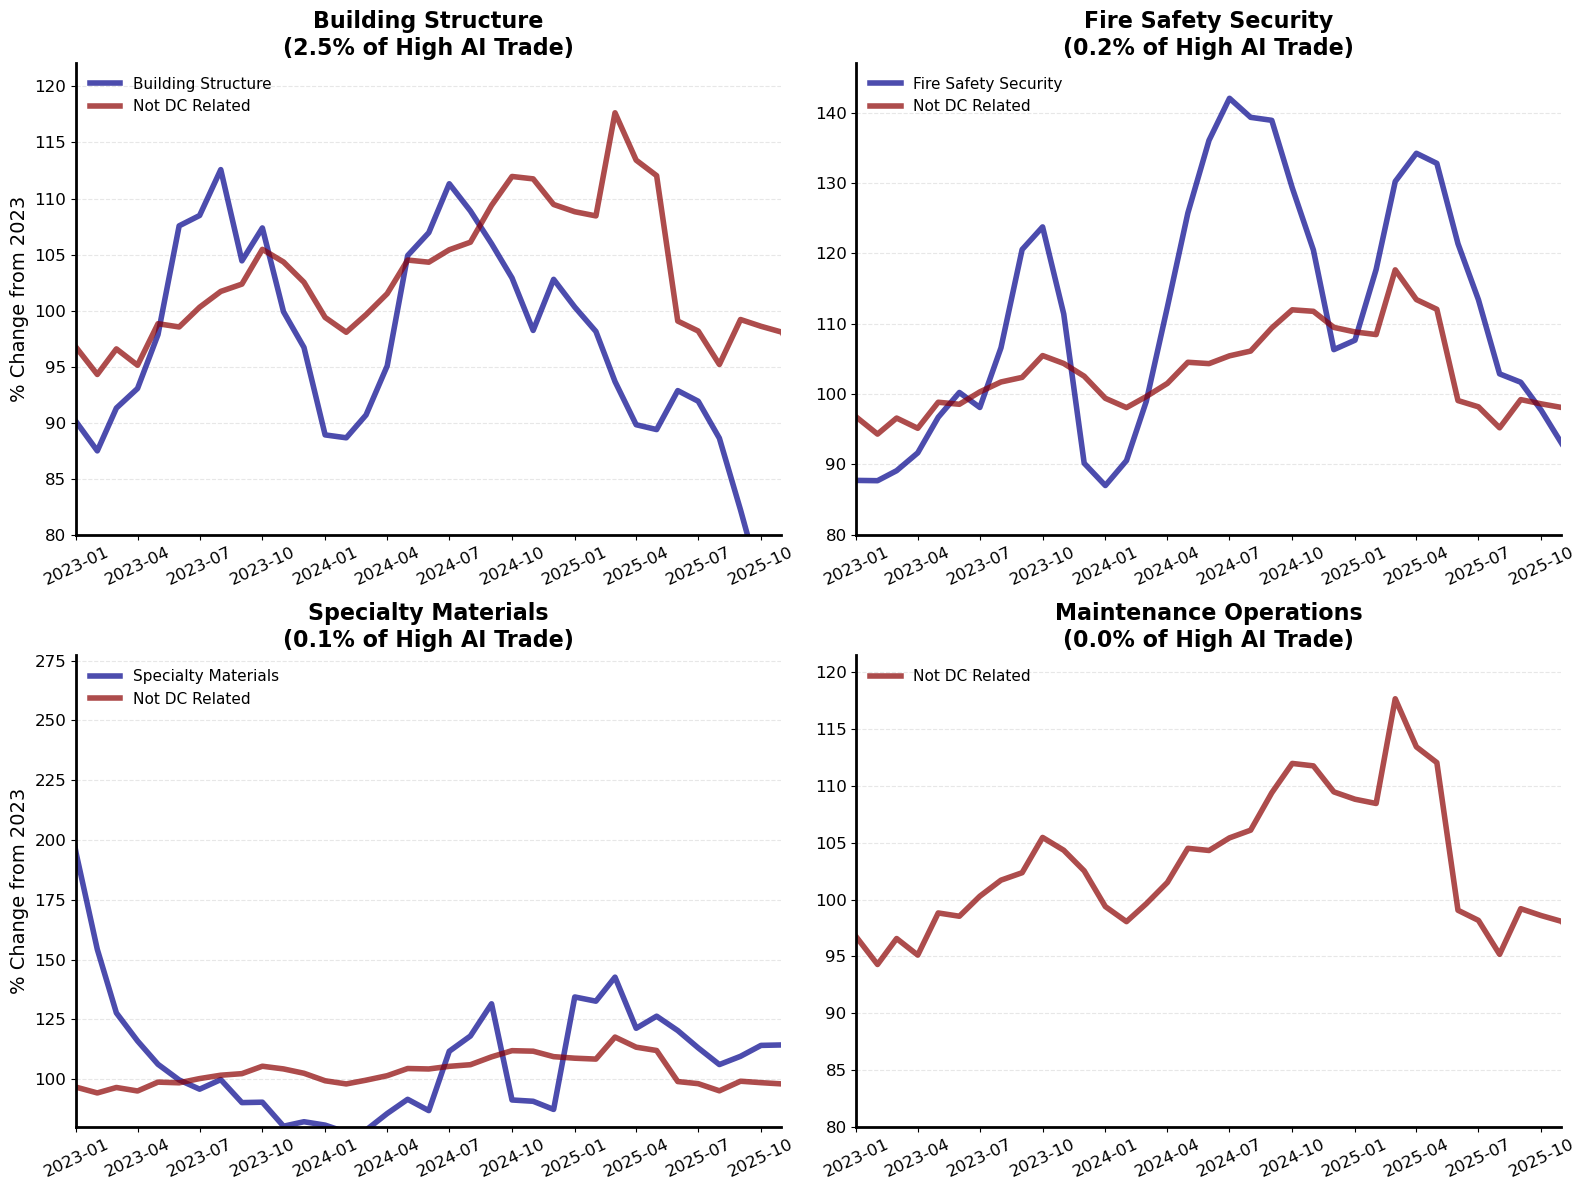

In [65]:
# PLOT BOTTOM 4 CATEGORIES (2x2 panel)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (cat, share) in enumerate(top_categories[4:8]):
    ax = axes[idx]
    
    # Get AI category data (High relevance only)
    cat_data = grp_cat_sum[grp_cat_sum['primary_category'] == cat].copy()
    cat_data.set_index('time', inplace=True)
    
    # Normalize to 2023 = 100
    if len(cat_data) > 0 and '2023' in cat_data.index:
        cat_2023_sum = cat_data["imports"].loc["2023"].sum()
        ax.plot(cat_data.index, (100*(12*cat_data["imports"] / cat_2023_sum)).rolling(window=3).mean(),
                color="darkblue", alpha=0.7, linewidth=4, label=cat.replace('_', ' '))
    
    # Plot Not_DC_Related data (all relevance levels)
    if len(not_dc_sum) > 0 and '2023' in not_dc_sum.index:
        not_dc_2023_sum = not_dc_sum["imports"].loc["2023"].sum()
        ax.plot(not_dc_sum.index, (100*(12*not_dc_sum["imports"] / not_dc_2023_sum)).rolling(window=3).mean(),
                color="darkred", alpha=0.7, linewidth=4, label='Not DC Related')
    
    # Formatting
    ax.set_title(f"{cat.replace('_', ' ')}\n({share:.1f}% of High AI Trade)", 
                 fontsize=16, fontweight='bold')
    ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,10,30)])
    ax.set_ylim(80,)
    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=12)
    
    if idx >= 2:  # Bottom row
        ax.set_xlabel("")
    if idx % 2 == 0:  # Left column
        ax.set_ylabel("% Change from 2023", fontsize=14)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    
    ax.legend(fontsize=11, frameon=False, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

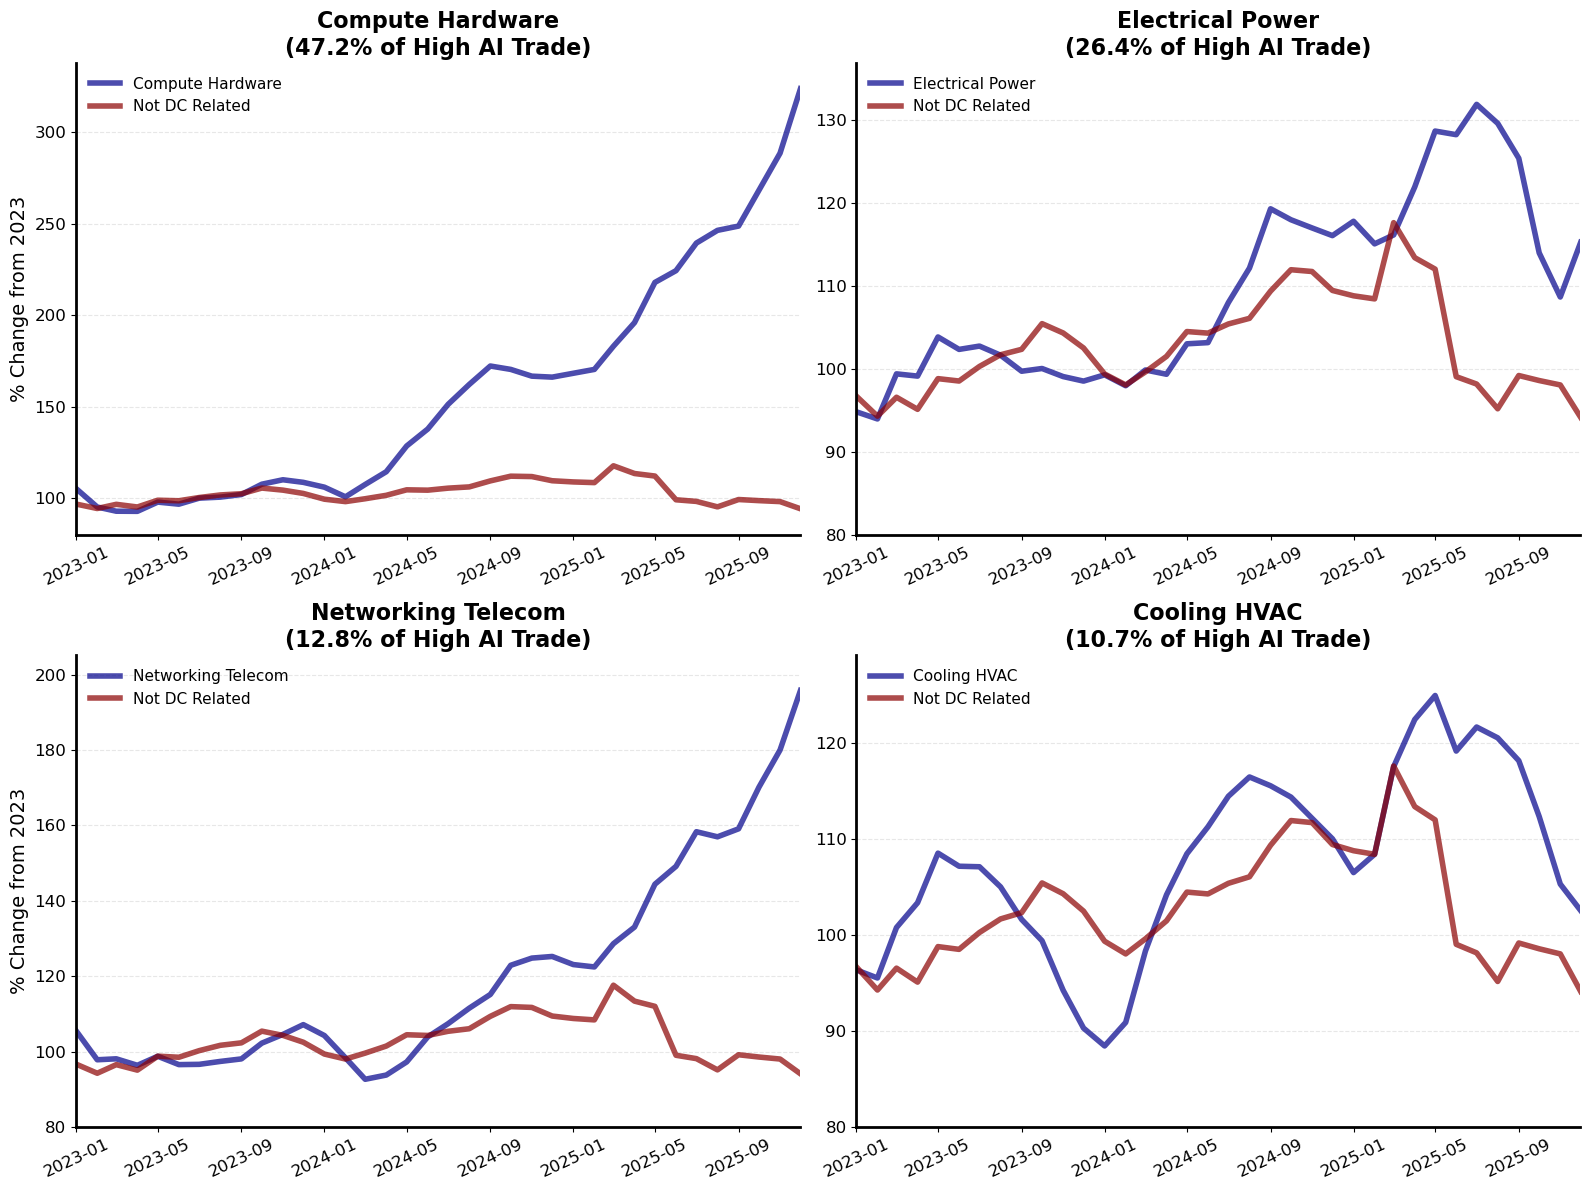

In [66]:
# PLOT TOP 4 CATEGORIES (2x2 panel)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (cat, share) in enumerate(top_categories[:4]):
    ax = axes[idx]
    
    # Get AI category data (High relevance only)
    cat_data = grp_cat_sum[grp_cat_sum['primary_category'] == cat].copy()
    cat_data.set_index('time', inplace=True)
    
    # Normalize to 2023 = 100
    if len(cat_data) > 0 and '2023' in cat_data.index:
        cat_2023_sum = cat_data["imports"].loc["2023"].sum()
        ax.plot(cat_data.index, (100*(12*cat_data["imports"] / cat_2023_sum)).rolling(window=3).mean(),
                color="darkblue", alpha=0.7, linewidth=4, label=cat.replace('_', ' '))
    
    # Plot Not_DC_Related data (all relevance levels)
    if len(not_dc_sum) > 0 and '2023' in not_dc_sum.index:
        not_dc_2023_sum = not_dc_sum["imports"].loc["2023"].sum()
        ax.plot(not_dc_sum.index, (100*(12*not_dc_sum["imports"] / not_dc_2023_sum)).rolling(window=3).mean(),
                color="darkred", alpha=0.7, linewidth=4, label='Not DC Related')
    
    # Formatting
    ax.set_title(f"{cat.replace('_', ' ')}\n({share:.1f}% of High AI Trade)", 
                 fontsize=16, fontweight='bold')
    ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,11,30)])
    ax.set_ylim(80,)
    ax.tick_params(axis='x', labelsize=12, rotation=25)
    ax.tick_params(axis='y', labelsize=12)
    
    if idx >= 2:  # Bottom row
        ax.set_xlabel("")
    if idx % 2 == 0:  # Left column
        ax.set_ylabel("% Change from 2023", fontsize=14)
    
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)
    
    ax.legend(fontsize=11, frameon=False, loc='upper left')
    ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

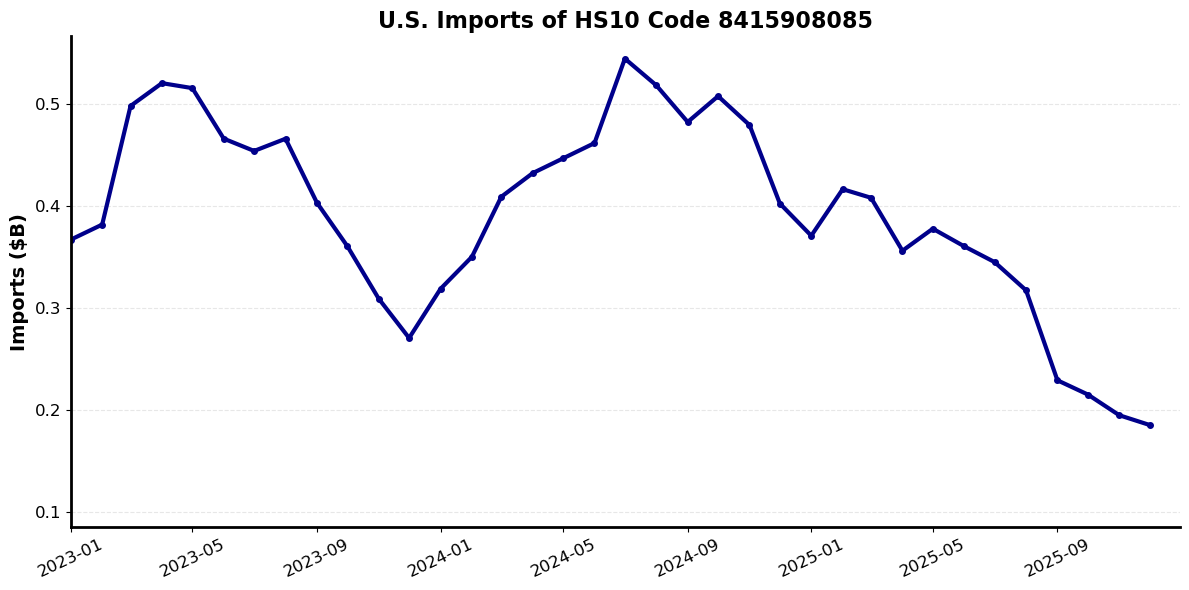


HS10 Code 8415908085 Summary:
  Total imports (all time): $41.17B
  Average monthly: $0.26B


In [ ]:
# Plot HS code 8542310040 over time in dollar values
hs_code = 8415908085
df_reset = df.reset_index()
hs_data = df_reset[df_reset['HS10'] == hs_code].copy()
hs_data_grouped = hs_data.groupby('time')['imports'].sum().reset_index()
hs_data_grouped.set_index('time', inplace=True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(hs_data_grouped.index, hs_data_grouped['imports'] / 1e9, 
        color='darkblue', linewidth=3, marker='o', markersize=4)

ax.set_title(f'U.S. Imports of HS10 Code {hs_code}', fontsize=16, fontweight='bold')
ax.set_ylabel('Imports ($B)', fontsize=14, fontweight='bold')
ax.set_xlim([dt.datetime(2023,1,1), dt.datetime(2025,12,31)])
ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
ax.grid(axis='y', alpha=0.3, linestyle='--')

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["left"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)

plt.tight_layout()
plt.show()

print(f"\nHS10 Code {hs_code} Summary:")
print(f"  Total imports (all time): ${hs_data_grouped['imports'].sum()/1e9:.2f}B")
print(f"  Average monthly: ${hs_data_grouped['imports'].mean()/1e9:.2f}B")

In [67]:
dfcountry = pd.read_parquet('ALL-data-current.parquet')

In [68]:
dfcountry.head()

,CTY_NAME,CON_VAL_MO,CAL_DUT_MO,I_COMMODITY,I_COMMODITY_SDESC,time,COMM_LVL,CTY_CODE
0,EUROPEAN UNION,1155822,0,8805290000,"GROUND FLYING TRAINERS AND PARTS THEREOF, NESOI",2013-01,HS10,0003
1,EUROPEAN UNION,216697,0,8903990500,CANOES (NORMALLY NOT USED WITH MOTORS OR SAILS),2013-01,HS10,0003
2,EUROPEAN UNION,105279,2843,8903991500,ROW BOATS(NORMALLY NOT USED WITH MOTRS/SAILS),2013-01,HS10,0003
3,EUROPEAN UNION,800582,16013,9002204000,FILTERS AND PARTS FOR PHOTOGRAPHIC USE,2013-01,HS10,0003
4,EUROPEAN UNION,597955,17343,9002208000,FILTERS AND PARTS EXCEPT PHOTOGRAPHIC,2013-01,HS10,0003


In [69]:
dfcountry = pd.read_parquet('ALL-data-current.parquet')

dfcountry.rename(columns={'I_COMMODITY': 'HS10'}, inplace=True)

dfcountry["HS2"] = dfcountry["HS10"].str[0:2]
dfcountry["HS4"] = dfcountry["HS10"].str[0:4]

dfcountry["HS10"] = dfcountry["HS10"].astype('int64')

dfcountry.time = pd.to_datetime(dfcountry.time, format="%Y-%m")

dfcountry["imports"] = dfcountry["CON_VAL_MO"].astype(float)

dfcountry["duty"] = dfcountry["CAL_DUT_MO"].astype(float)

dfcountry.rename({"I_COMMODITY_SDESC": "short_description"}, axis = 1, inplace= True)

# Remove volatile/special HS2 categories
# These categories have prices that are either:
# - Extremely volatile (oil, precious metals)
# - Lumpy/irregular (aircraft)
# - Unreliable/special (pharmaceuticals, special provisions)
excluded_hs2 = ["27", "71", "98", "99"]
dfcountry = dfcountry[~dfcountry["HS2"].isin(excluded_hs2)]

excluded_cntry = ["TOTAL FOR ALL COUNTRIES", "USMCA (NAFTA)", "EUROPEAN UNION"]
dfcountry = dfcountry[~dfcountry["CTY_NAME"].isin(excluded_cntry)]

# Merge Relevance category from matlist onto df
dfcountry = dfcountry.merge(matlist[['HS10', 'relevance', 'primary_category', "reasoning"	]], on='HS10', how='left')

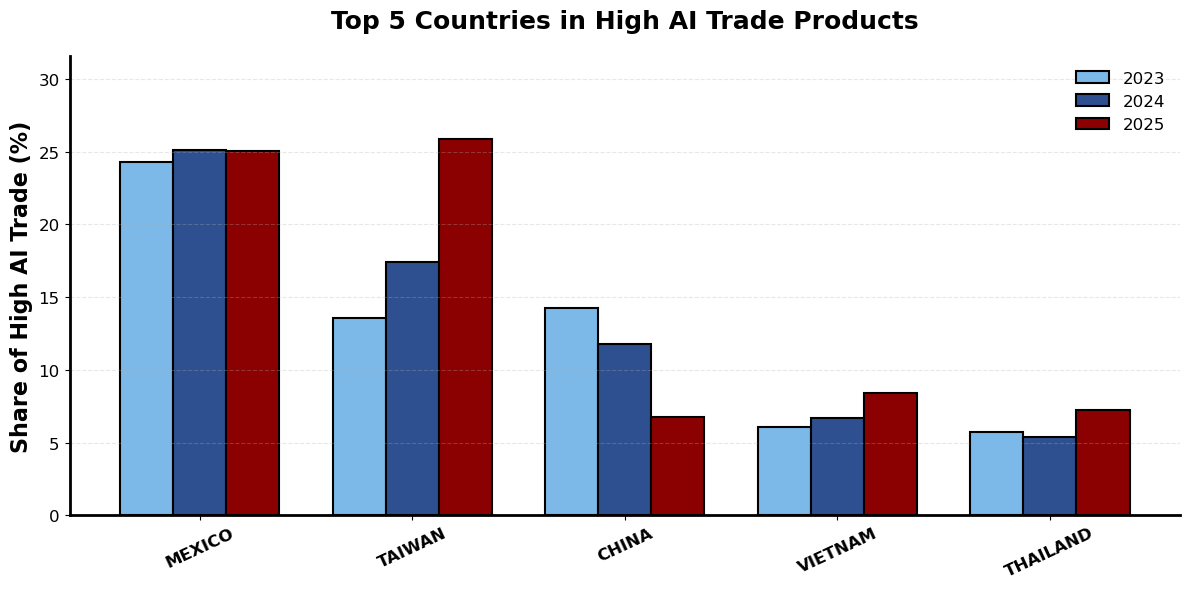


Top 5 countries by share of High AI trade:
  MEXICO: 2023=24.32% | 2024=25.12% | 2025=25.08%
  TAIWAN: 2023=13.57% | 2024=17.43% | 2025=25.90%
  CHINA: 2023=14.22% | 2024=11.78% | 2025=6.77%
  VIETNAM: 2023=6.09% | 2024=6.69% | 2025=8.43%
  THAILAND: 2023=5.70% | 2024=5.41% | 2025=7.27%

High-AI import growth (2025 vs 2024):
  Canada: -4.2%
  Mexico: 40.7%

Total import growth (2025 vs 2024):
  Canada: -8.3%
  Mexico: 6.4%

Appended to tables/ai-trade-results.tex:
  \canadaHighAiImportGrowthTwentyFiveVsTwentyFour = -4.2
  \mexicoHighAiImportGrowthTwentyFiveVsTwentyFour = 40.7
  \canadaTotalImportGrowthTwentyFiveVsTwentyFour = -8.3
  \mexicoTotalImportGrowthTwentyFiveVsTwentyFour = 6.4


In [70]:
# Top 5 countries in High AI trade products, split by year (2023, 2024, 2025)

period_years = [2023, 2024, 2025]

country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Select top 5 countries based on combined 2024-2025 imports
country_imports_total = (
    country_high[country_high['time'].dt.year.isin([2024, 2025])]
    .groupby('CTY_NAME', observed=True)['imports']
    .sum()
    .sort_values(ascending=False)
)
top5_countries = country_imports_total.head(5).index.tolist()

# Compute yearly shares: country high-AI imports / total high-AI imports in that year
yearly_country_imports = (
    country_high[country_high['CTY_NAME'].isin(top5_countries)]
    .groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

yearly_high_totals = (
    country_high.groupby(country_high['time'].dt.year, observed=True)['imports']
    .sum()
)

plot_df = pd.DataFrame({
    '2023': (yearly_country_imports[2023] / yearly_high_totals.loc[2023]) * 100,
    '2024': (yearly_country_imports[2024] / yearly_high_totals.loc[2024]) * 100,
    '2025': (yearly_country_imports[2025] / yearly_high_totals.loc[2025]) * 100
}).loc[top5_countries]

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(plot_df.index))
width = 0.25

bars_2023 = ax.bar(
    x - width,
    plot_df['2023'].values,
    width,
    label='2023',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

bars_2024 = ax.bar(
    x,
    plot_df['2024'].values,
    width,
    label='2024',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_2025 = ax.bar(
    x + width,
    plot_df['2025'].values,
    width,
    label='2025',
    color='#8B0000',
    edgecolor='black',
    linewidth=1.5
)

# Formatting (consistent with existing style)
ax.set_ylabel('Share of High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 5 Countries in High AI Trade Products', fontsize=18, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(plot_df['2023'].max(), plot_df['2024'].max(), plot_df['2025'].max()) * 1.22)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.legend(fontsize=12, frameon=False, loc='upper right')

plt.savefig(figfile+"ai-by-country.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-by-country.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()

# Compute import growth in 2025 relative to 2024 for Canada and Mexico (High AI products)
country_year_imports_high = (
    country_high.groupby(['CTY_NAME', country_high['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=period_years, fill_value=0)
)

canada_2024_high = country_year_imports_high.loc['CANADA', 2024] if 'CANADA' in country_year_imports_high.index else 0.0
canada_2025_high = country_year_imports_high.loc['CANADA', 2025] if 'CANADA' in country_year_imports_high.index else 0.0
mexico_2024_high = country_year_imports_high.loc['MEXICO', 2024] if 'MEXICO' in country_year_imports_high.index else 0.0
mexico_2025_high = country_year_imports_high.loc['MEXICO', 2025] if 'MEXICO' in country_year_imports_high.index else 0.0

canada_growth_2025_vs_2024_high = ((canada_2025_high - canada_2024_high) / canada_2024_high) * 100 if canada_2024_high > 0 else 0.0
mexico_growth_2025_vs_2024_high = ((mexico_2025_high - mexico_2024_high) / mexico_2024_high) * 100 if mexico_2024_high > 0 else 0.0

# Compute total import growth in 2025 relative to 2024 for Canada and Mexico (all relevance)
country_total = dfcountry[dfcountry['time'].dt.year.isin([2024, 2025])].copy()
country_year_imports_total = (
    country_total.groupby(['CTY_NAME', country_total['time'].dt.year], observed=True)['imports']
    .sum()
    .unstack(fill_value=0)
    .reindex(columns=[2024, 2025], fill_value=0)
)

canada_2024_total = country_year_imports_total.loc['CANADA', 2024] if 'CANADA' in country_year_imports_total.index else 0.0
canada_2025_total = country_year_imports_total.loc['CANADA', 2025] if 'CANADA' in country_year_imports_total.index else 0.0
mexico_2024_total = country_year_imports_total.loc['MEXICO', 2024] if 'MEXICO' in country_year_imports_total.index else 0.0
mexico_2025_total = country_year_imports_total.loc['MEXICO', 2025] if 'MEXICO' in country_year_imports_total.index else 0.0

canada_growth_2025_vs_2024_total = ((canada_2025_total - canada_2024_total) / canada_2024_total) * 100 if canada_2024_total > 0 else 0.0
mexico_growth_2025_vs_2024_total = ((mexico_2025_total - mexico_2024_total) / mexico_2024_total) * 100 if mexico_2024_total > 0 else 0.0

with open(texfile, 'a') as f:
    f.write(f'\\newcommand{{\\canadaHighAiImportGrowthTwentyFiveVsTwentyFour}}{{{canada_growth_2025_vs_2024_high:.1f}}} % Canada high-AI import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\newcommand{{\\mexicoHighAiImportGrowthTwentyFiveVsTwentyFour}}{{{mexico_growth_2025_vs_2024_high:.1f}}} % Mexico high-AI import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\newcommand{{\\canadaTotalImportGrowthTwentyFiveVsTwentyFour}}{{{canada_growth_2025_vs_2024_total:.1f}}} % Canada total import growth in 2025 vs 2024 (%)\n')
    f.write(f'\\newcommand{{\\mexicoTotalImportGrowthTwentyFiveVsTwentyFour}}{{{mexico_growth_2025_vs_2024_total:.1f}}} % Mexico total import growth in 2025 vs 2024 (%)\n')

print('\nTop 5 countries by share of High AI trade:')
for country in plot_df.index:
    print(
        f"  {country}: 2023={plot_df.loc[country, '2023']:.2f}% | "
        f"2024={plot_df.loc[country, '2024']:.2f}% | "
        f"2025={plot_df.loc[country, '2025']:.2f}%"
    )

print('\nHigh-AI import growth (2025 vs 2024):')
print(f"  Canada: {canada_growth_2025_vs_2024_high:.1f}%")
print(f"  Mexico: {mexico_growth_2025_vs_2024_high:.1f}%")

print('\nTotal import growth (2025 vs 2024):')
print(f"  Canada: {canada_growth_2025_vs_2024_total:.1f}%")
print(f"  Mexico: {mexico_growth_2025_vs_2024_total:.1f}%")

print(f"\nAppended to {texfile}:")
print(f"  \\canadaHighAiImportGrowthTwentyFiveVsTwentyFour = {canada_growth_2025_vs_2024_high:.1f}")
print(f"  \\mexicoHighAiImportGrowthTwentyFiveVsTwentyFour = {mexico_growth_2025_vs_2024_high:.1f}")
print(f"  \\canadaTotalImportGrowthTwentyFiveVsTwentyFour = {canada_growth_2025_vs_2024_total:.1f}")
print(f"  \\mexicoTotalImportGrowthTwentyFiveVsTwentyFour = {mexico_growth_2025_vs_2024_total:.1f}")

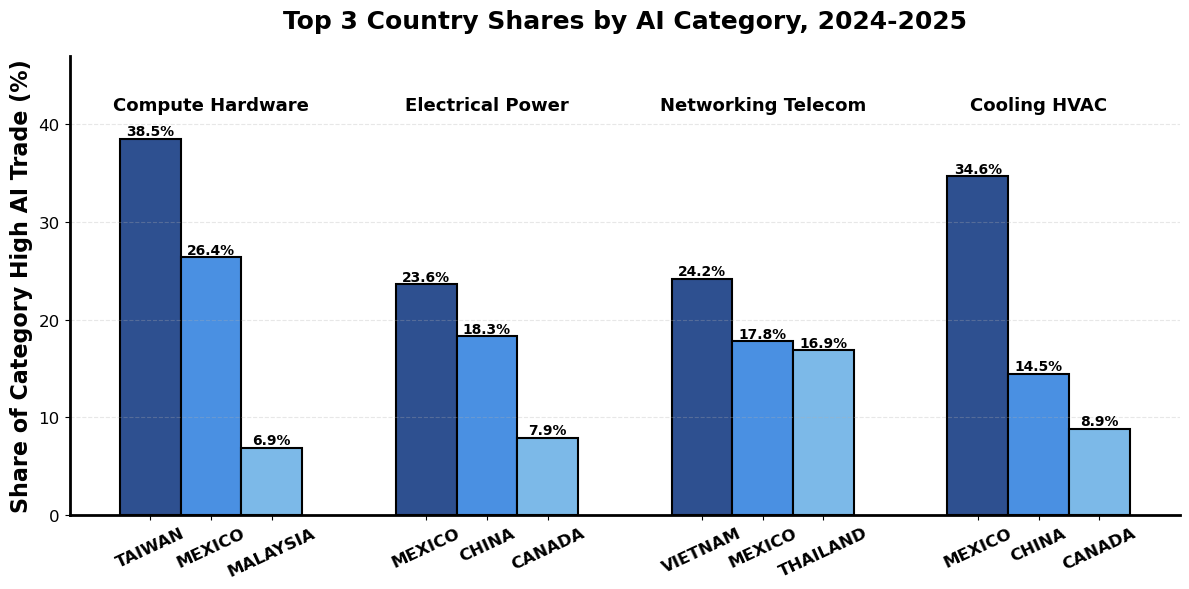


Top 3 country shares within each category (2024-2025):
  Compute Hardware:
    1) TAIWAN: 38.5%
    2) MEXICO: 26.4%
    3) MALAYSIA: 6.9%
  Electrical Power:
    1) MEXICO: 23.6%
    2) CHINA: 18.3%
    3) CANADA: 7.9%
  Networking Telecom:
    1) VIETNAM: 24.2%
    2) MEXICO: 17.8%
    3) THAILAND: 16.9%
  Cooling HVAC:
    1) MEXICO: 34.6%
    2) CHINA: 14.5%
    3) CANADA: 8.9%


In [71]:
# Top 3 country shares within each top AI category (2024-2025)

period_years = [2024, 2025]
category_list = ['Compute_Hardware', 'Electrical_Power', 'Networking_Telecom', 'Cooling_HVAC']

cat_country_high = dfcountry[
    (dfcountry['relevance'] == 'High') &
    (dfcountry['primary_category'].isin(category_list)) &
    (dfcountry['time'].dt.year.isin(period_years))
] .copy()

# Compute top-3 country shares within each category
share_by_rank = {'Top 1': [], 'Top 2': [], 'Top 3': []}
country_names_by_cat = {}

for category in category_list:
    category_data = cat_country_high[cat_country_high['primary_category'] == category]
    country_imports = category_data.groupby('CTY_NAME', observed=True)['imports'].sum().sort_values(ascending=False)

    category_total = country_imports.sum()
    top3 = country_imports.head(3)

    # Pad if fewer than 3 countries
    top3_shares = (top3 / category_total * 100).tolist()
    top3_names = top3.index.tolist()

    while len(top3_shares) < 3:
        top3_shares.append(0.0)
        top3_names.append('N/A')

    share_by_rank['Top 1'].append(top3_shares[0])
    share_by_rank['Top 2'].append(top3_shares[1])
    share_by_rank['Top 3'].append(top3_shares[2])

    country_names_by_cat[category] = top3_names

# Plot grouped bars
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(category_list))
width = 0.22

bars_top1 = ax.bar(
    x - width,
    share_by_rank['Top 1'],
    width,
    label='Top 1 Country',
    color='#2E5090',
    edgecolor='black',
    linewidth=1.5
)

bars_top2 = ax.bar(
    x,
    share_by_rank['Top 2'],
    width,
    label='Top 2 Country',
    color='#4A90E2',
    edgecolor='black',
    linewidth=1.5
)

bars_top3 = ax.bar(
    x + width,
    share_by_rank['Top 3'],
    width,
    label='Top 3 Country',
    color='#7CB9E8',
    edgecolor='black',
    linewidth=1.5
)

# Labels on bars (percent values)
for bars in [bars_top1, bars_top2, bars_top3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.05,
            f'{height:.1f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# X-axis labels: country names under each bar
bar_positions = []
bar_labels = []
for idx, category in enumerate(category_list):
    c1, c2, c3 = country_names_by_cat[category]
    bar_positions.extend([x[idx] - width, x[idx], x[idx] + width])
    bar_labels.extend([c1, c2, c3])

ax.set_xticks(bar_positions)
ax.set_xticklabels(bar_labels)

# Category annotations centered on middle bar of each group (~42%)
max_share = max(max(share_by_rank['Top 1']), max(share_by_rank['Top 2']), max(share_by_rank['Top 3']))
category_label_y = 42
top_ylim = max(max_share * 1.22, category_label_y + 3)

for idx, category in enumerate(category_list):
    ax.text(
        x[idx],
        category_label_y,
        category.replace('_', ' '),
        ha='center',
        va='center',
        fontsize=13,
        fontweight='bold'
    )

# Formatting (consistent style)
ax.set_ylabel('Share of Category High AI Trade (%)', fontsize=16, fontweight='bold')
ax.set_title('Top 3 Country Shares by AI Category, 2024-2025', fontsize=18, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, top_ylim)

ax.tick_params(axis='x', labelsize=12, rotation=25)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontweight('bold')

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

plt.savefig(figfile+"ai-by-country-category.png", bbox_inches = "tight")
plt.savefig(figfile+"ai-by-country-category.pdf", bbox_inches = "tight")

plt.tight_layout()
plt.show()

print('\nTop 3 country shares within each category (2024-2025):')
for category in category_list:
    c1, c2, c3 = country_names_by_cat[category]
    i = category_list.index(category)
    print(f"  {category.replace('_', ' ')}:")
    print(f"    1) {c1}: {share_by_rank['Top 1'][i]:.1f}%")
    print(f"    2) {c2}: {share_by_rank['Top 2'][i]:.1f}%")
    print(f"    3) {c3}: {share_by_rank['Top 3'][i]:.1f}%")